---
##Configuration

In [1]:
import os
import random
from pathlib import Path


In [2]:
# Paths.
DATA_PATH = Path("/content/merged_crop_data.csv")
OUTPUT_DIR = Path("/content/outputs") if Path("/content").exists() else Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Could not find merged_crop_data.csv. In Colab, upload it to /content "
        "or mount Drive and place it at /content/drive/MyDrive/merged_crop_data.csv."
    )

In [3]:
# Experiment constants
FINAL_TEST_START = 2020   # all years >= this are held out as the final test block
RANDOM_STATE     = 42
WINDOW           = 3      # sequence window for LSTM / GRU / CNN models
DL_N_RUNS        = 10     # independent runs for sequence models (stochasticity stabilisation)
MAX_EPOCHS       = 150    # high cap; EarlyStopping usually halts training well before this
DL_VERBOSE       = 0      # set to 1 or 2 to watch epoch-level training logs in Colab


In [4]:
# Climate columns present in the raw CSV (VPD and RH are dropped after profiling)
CLIMATE_COLS_RAW = [
    "GDD", "HEAT_STRESS_DAYS", "PRECIP", "PET", "P_MINUS_PET",
    "TMEAN", "TMX", "TMN", "DTR", "VAP_KPA",
]

# Climate columns retained after multicollinearity reduction (set in EDA section)
# This list is updated by the EDA section; used in feature engineering and anomaly computation.
CLIMATE_COLS: list = []   # populated by EDA Section


In [5]:
print(f"Data path  : {DATA_PATH}")
print(f"Output dir : {OUTPUT_DIR}")
print(f"Test start : {FINAL_TEST_START}")
print(f"Random seed: {RANDOM_STATE}")
print(f"DL runs    : {DL_N_RUNS}")
print(f"Max epochs : {MAX_EPOCHS}")
print(f"DL verbose : {DL_VERBOSE}")


Data path  : /content/merged_crop_data.csv
Output dir : /content/outputs
Test start : 2020
Random seed: 42
DL runs    : 10
Max epochs : 150
DL verbose : 0


---
##Imports

In [6]:
import json
import warnings
import logging
from dataclasses import dataclass
from typing import Iterable

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from scipy.stats import pearsonr, spearmanr, kendalltau
from sklearn.feature_selection import mutual_info_regression
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.base import clone
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PowerTransformer, StandardScaler
from sklearn.svm import SVR

import lightgbm as lgb
import xgboost  as xgb

import tensorflow as tf
tf.get_logger().setLevel('ERROR')
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import (
    BatchNormalization, Bidirectional, Conv1D, Dense, Dropout,
    GlobalAveragePooling1D, GRU, Input, LSTM,
    LayerNormalization, MultiHeadAttention,
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam


In [7]:
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
try:
    tf.config.threading.set_intra_op_parallelism_threads(1)
    tf.config.threading.set_inter_op_parallelism_threads(1)
except Exception:
    pass

warnings.filterwarnings("ignore")
logging.getLogger("lightgbm").setLevel(logging.ERROR)


In [8]:
print(f"TensorFlow version : {tf.__version__}")
print(f"NumPy version      : {np.__version__}")
print(f"Pandas version     : {pd.__version__}")


TensorFlow version : 2.20.0
NumPy version      : 2.0.2
Pandas version     : 2.2.2


---
##Utility Functions

In [9]:
def ensure_output_dir() -> None:
    """Create output directory if it does not exist."""
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Root-mean-squared error."""
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def metrics_dict(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """Return RMSE, MAE, and R² as a dictionary."""
    return {
        "rmse": rmse(y_true, y_pred),
        "mae" : float(mean_absolute_error(y_true, y_pred)),
        "r2"  : float(r2_score(y_true, y_pred)),
    }

def finite_or_none(values: np.ndarray) -> np.ndarray | None:
    """Return array only if all values are finite; otherwise None."""
    arr = np.asarray(values, dtype=float)
    return arr if np.all(np.isfinite(arr)) else None

def slugify(name: str) -> str:
    """Convert a label to a filesystem-safe slug."""
    return name.lower().replace(" ", "_").replace("-", "_")

ensure_output_dir()


---
##Data Loading & Profiling

In [10]:
def load_data() -> pd.DataFrame:
    """Load raw CSV and normalise column names to uppercase."""
    df = pd.read_csv(DATA_PATH)
    df.columns = [col.strip().upper() for col in df.columns]
    df['YEAR'] = df['YEAR'].astype(int)
    return df

def profile_dataset(df: pd.DataFrame) -> dict:
    """
    Check:
    - Shape, year range, district/crop counts
    - Constant numeric columns (zero-variance features → must be dropped)
    - Missing values per column
    - Consistency of PRODUCTION / AREA == YIELD
    - Rows with suspiciously small AREA values
    """
    numeric       = df.select_dtypes(include="number")
    constant_cols = [col for col in numeric.columns if numeric[col].nunique(dropna=False) <= 1]
    yield_check   = (df["PRODUCTION"] / df["AREA"]).replace([np.inf, -np.inf], np.nan)
    yield_abs_err = (yield_check - df["YIELD"]).abs()

    return {
        "shape"                       : list(df.shape),
        "year_min"                    : int(df["YEAR"].min()),
        "year_max"                    : int(df["YEAR"].max()),
        "districts"                   : int(df["DISTRICT"].nunique()),
        "crops"                       : int(df["CROP"].nunique()),
        "district_crop_panels"        : int(df.groupby(["DISTRICT", "CROP"]).ngroups),
        "constant_numeric_columns"    : constant_cols,
        "missing_by_column"           : df.isna().sum().to_dict(),
        "yield_formula_mean_abs_error": float(yield_abs_err.mean()),
        "yield_formula_max_abs_error" : float(yield_abs_err.max()),
        "rows_with_area_below_1"      : int((df["AREA"] < 1).sum()),
    }


In [11]:
raw_df  = load_data()
profile = profile_dataset(raw_df)

print(f"Shape               : {tuple(profile['shape'])}")
print(f"Year range          : {profile['year_min']} – {profile['year_max']}")
print(f"Districts           : {profile['districts']}")
print(f"Crops               : {profile['crops']}")
print(f"District-crop panels: {profile['district_crop_panels']}")
print(f"Constant columns    : {profile['constant_numeric_columns']}")
print(f"Rows with AREA < 1  : {profile['rows_with_area_below_1']}")
print(f"YIELD formula MAE   : {profile['yield_formula_mean_abs_error']:.4f}")
print("\nMissing values per column:")
missing = {k: v for k, v in profile['missing_by_column'].items() if v > 0}
print(missing if missing else "  None")

# Save profile
(OUTPUT_DIR / "dataset_profile.json").write_text(json.dumps(profile, indent=2), encoding="utf-8")


Shape               : (1525, 18)
Year range          : 2000 – 2024
Districts           : 17
Crops               : 4
District-crop panels: 61
Constant columns    : ['VPD', 'RH']
Rows with AREA < 1  : 232
YIELD formula MAE   : 0.0772

Missing values per column:
  None


664

In [12]:

# Drop constant sensor columns flagged by the profiler
# VPD = 0 and RH = 100 throughout the entire dataset (zero variance).
COLS_TO_DROP_CONSTANT = profile["constant_numeric_columns"]
if COLS_TO_DROP_CONSTANT:
    raw_df = raw_df.drop(columns=COLS_TO_DROP_CONSTANT, errors="ignore")
    print(f"Dropped constant columns: {COLS_TO_DROP_CONSTANT}")
else:
    print("No constant columns found.")

print(f"Remaining columns ({raw_df.shape[1]}): {raw_df.columns.tolist()}")


Dropped constant columns: ['VPD', 'RH']
Remaining columns (16): ['DISTRICT', 'YEAR', 'PRODUCTION', 'AREA', 'YIELD', 'GDD', 'HEAT_STRESS_DAYS', 'PRECIP', 'PET', 'P_MINUS_PET', 'TMEAN', 'TMX', 'TMN', 'DTR', 'VAP_KPA', 'CROP']


In [13]:
raw_df.head()

,DISTRICT,YEAR,PRODUCTION,AREA,YIELD,GDD,HEAT_STRESS_DAYS,PRECIP,PET,P_MINUS_PET,TMEAN,TMX,TMN,DTR,VAP_KPA,CROP
0,Khairpur,2000,16.89,5.96,2.83,6623.600231,204.699994,36.30000,49.300000,-13.000002,32.125000,39.450000,24.887500,14.562500,22.2250,RICE
1,Khairpur,2001,11.03,5.34,2.07,6526.400209,205.475012,52.40000,48.500000,3.899998,31.725000,39.050000,24.487501,14.562500,22.1125,RICE
2,Khairpur,2002,8.57,3.71,2.31,6675.900082,204.699994,13.00000,49.400000,-36.400000,32.337500,39.662502,25.100000,14.562500,22.4625,RICE
3,Khairpur,2003,13.56,2.14,6.33,6414.700140,197.725012,183.90001,48.300003,135.600020,31.275002,38.600002,24.037500,14.562501,21.6000,RICE
4,Khairpur,2004,7.46,3.73,2.00,6563.800013,188.425006,16.30000,49.100002,-32.800000,31.887500,39.212500,24.650000,14.562500,21.7625,RICE


---
## Plots

In [14]:
import math
import os
from matplotlib.patches import Patch

plot_df = raw_df.copy()
plot_df["YEAR"] = plot_df["YEAR"].astype(int)
plot_df["CROP"] = plot_df["CROP"].str.upper()
plot_df["DISTRICT"] = plot_df["DISTRICT"].str.title()

if "VAP" not in plot_df.columns and "VAP_KPA" in plot_df.columns:
    plot_df["VAP"] = plot_df["VAP_KPA"] * 10

FIGURES_DIR = OUTPUT_DIR / "reference_eda_figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", font_scale=1.3)

crop_colors_soft = {
    "COTTON": "#7FAEDC",
    "SUGARCANE": "#7FC8B2",
    "WHEAT": "#F4C27A",
    "RICE": "#E58FA2",
}

crop_colors_line = {
    "RICE": "#1f77b4",
    "WHEAT": "#ff7f0e",
    "COTTON": "#2ca02c",
    "SUGARCANE": "#d62728",
}

climate_palette = {
    "TMEAN": "#1f77b4",
    "VAP": "#ff7f0e",
    "PRECIP": "#2ca02c",
    "DTR": "#9467bd",
    "PET": "#d62728",
    "TMN": "#17becf",
    "TMX": "#bcbd22",
}

def save_reference_plot(filename: str):
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()

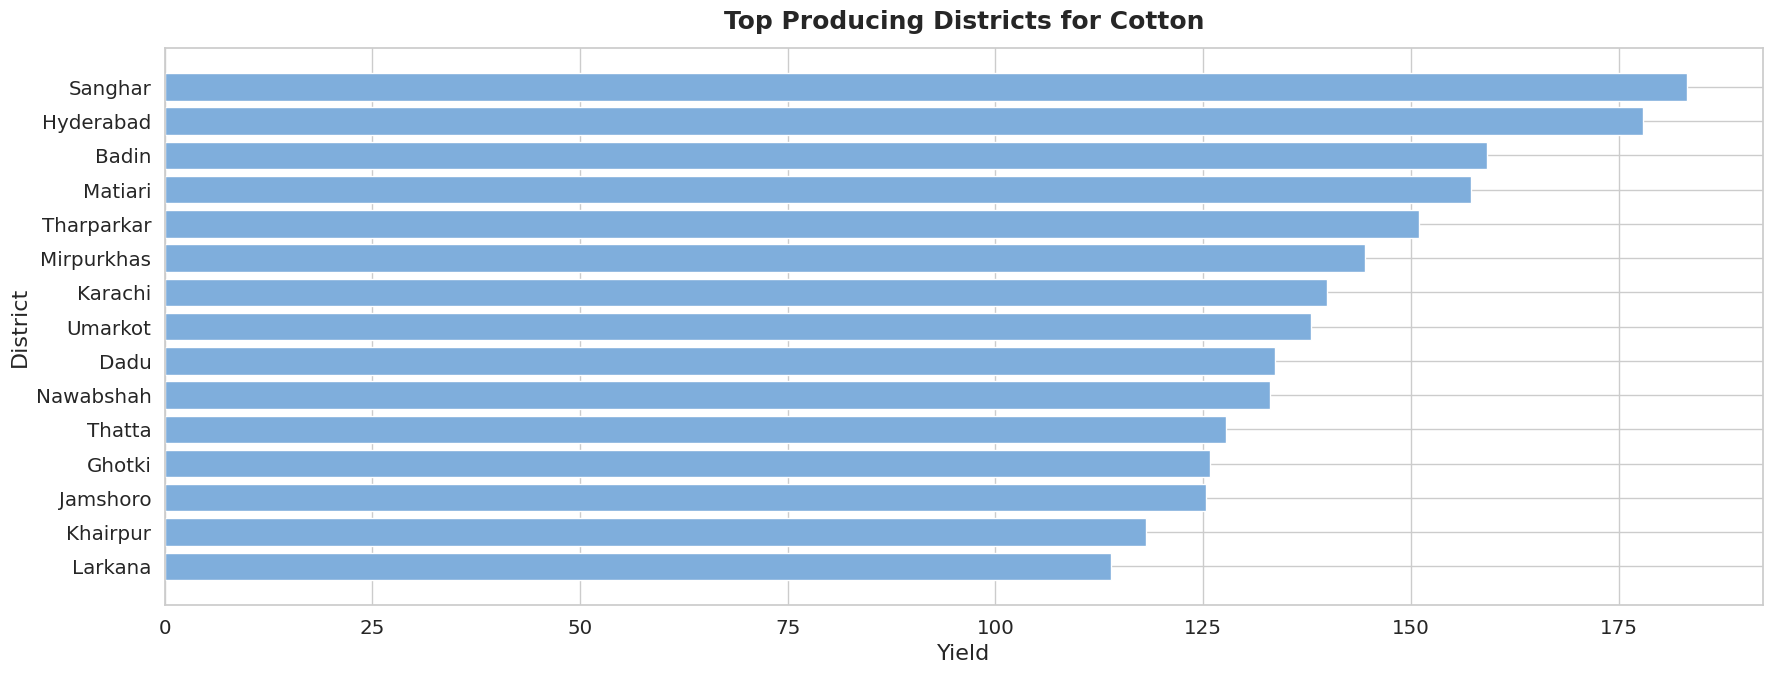

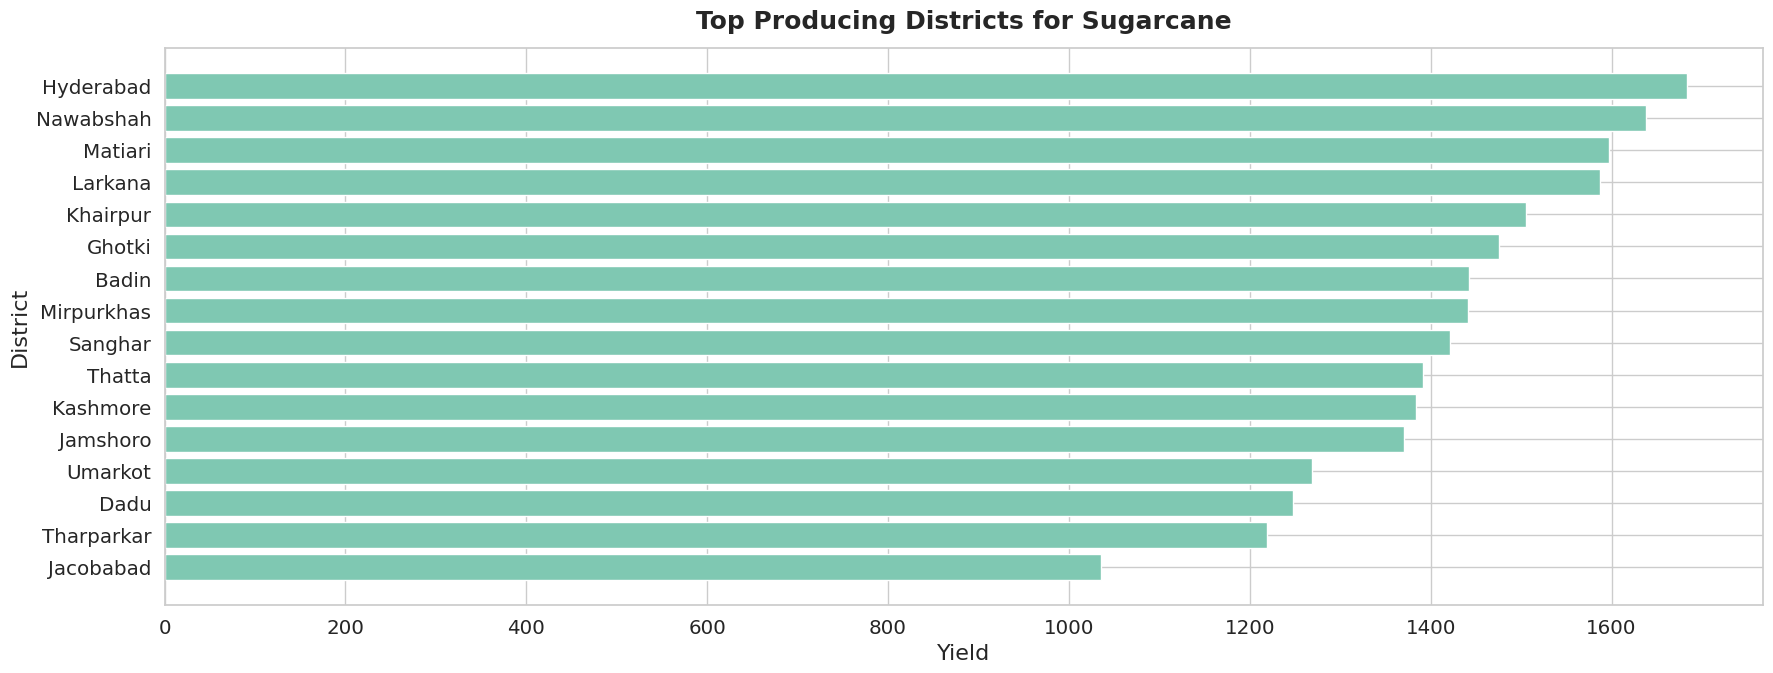

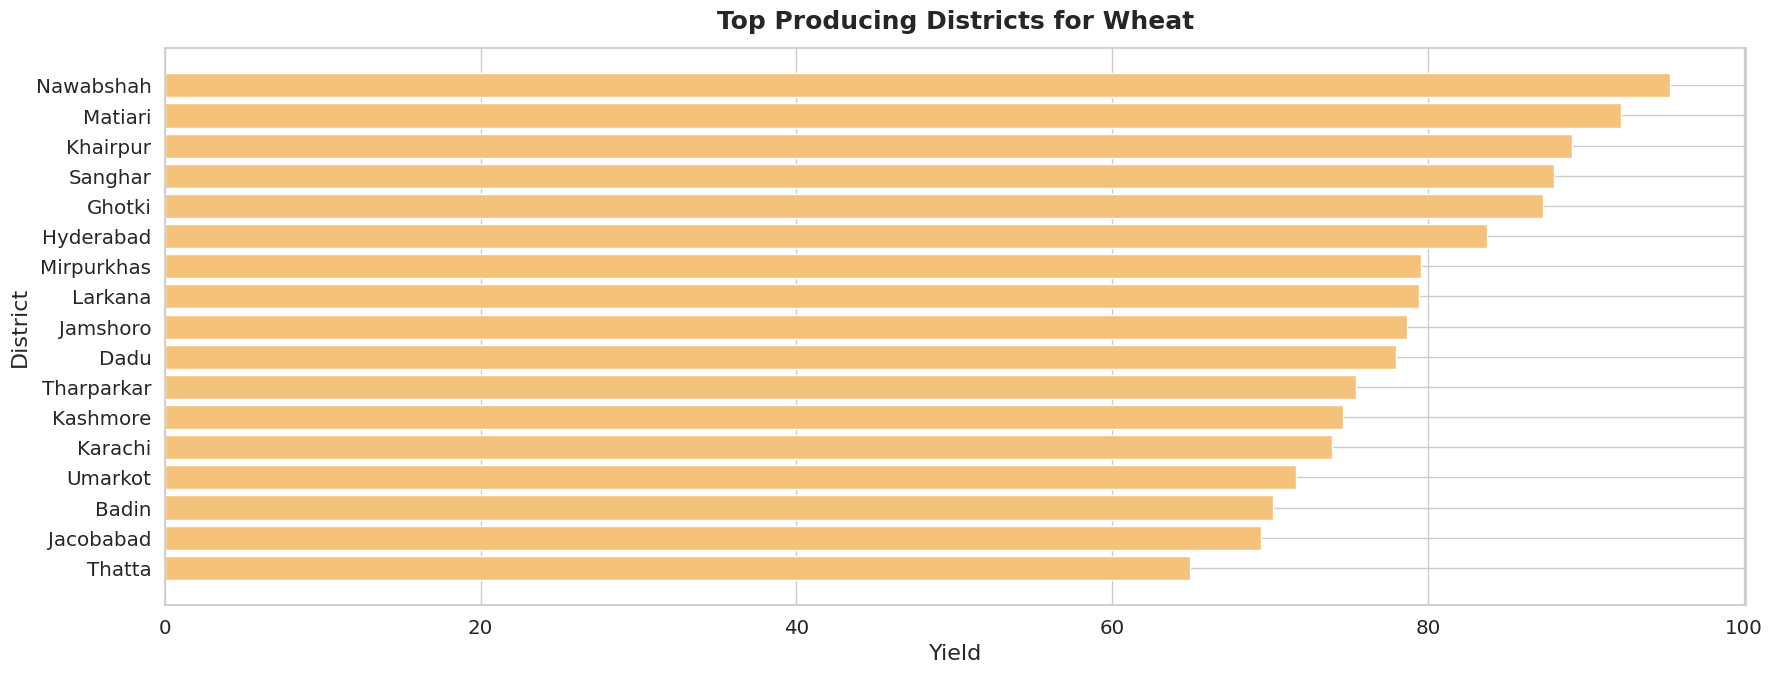

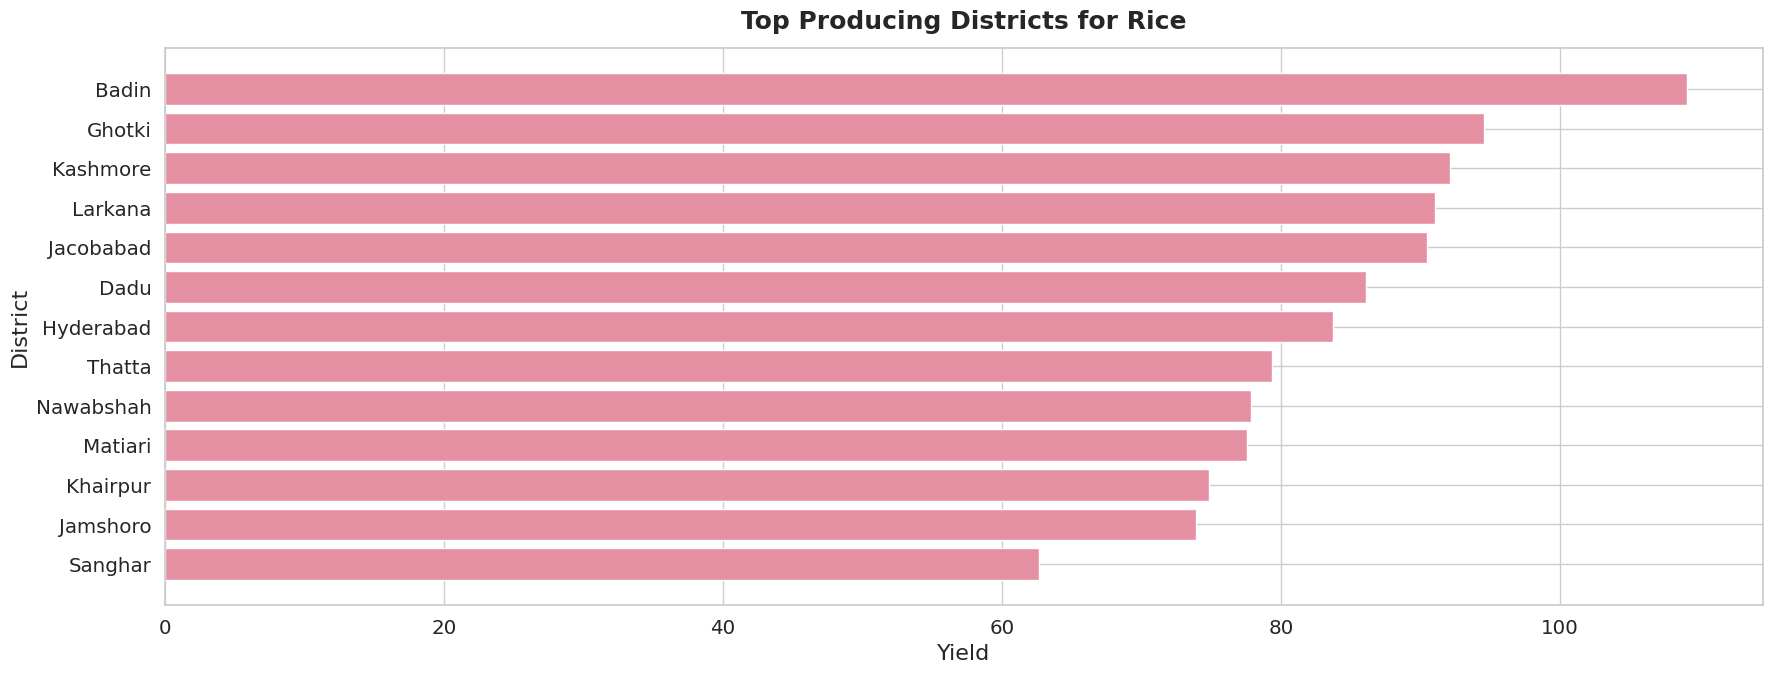

In [15]:
# Top Producing Districts for each Crop
def plot_total_yield_ranking(crop_name):
    crop_df = plot_df[plot_df["CROP"] == crop_name]

    total_yield = (
        crop_df
        .groupby("DISTRICT")["YIELD"]
        .sum()
        .sort_values(ascending=False)
    )

    color = crop_colors_soft.get(crop_name, "#B0B0B0")

    plt.figure(figsize=(18, 7))
    plt.barh(total_yield.index, total_yield.values, color=color)
    plt.gca().invert_yaxis()

    plt.title(
        f"Top Producing Districts for {crop_name.capitalize()}",
        fontsize=18, y=1.02, weight="bold"
    )
    plt.xlabel("Yield", fontsize=16)
    plt.ylabel("District", fontsize=16)

    save_reference_plot(f"{crop_name.lower()}_top_producing_districts.png")

for crop in ["COTTON", "SUGARCANE", "WHEAT", "RICE"]:
    plot_total_yield_ranking(crop)

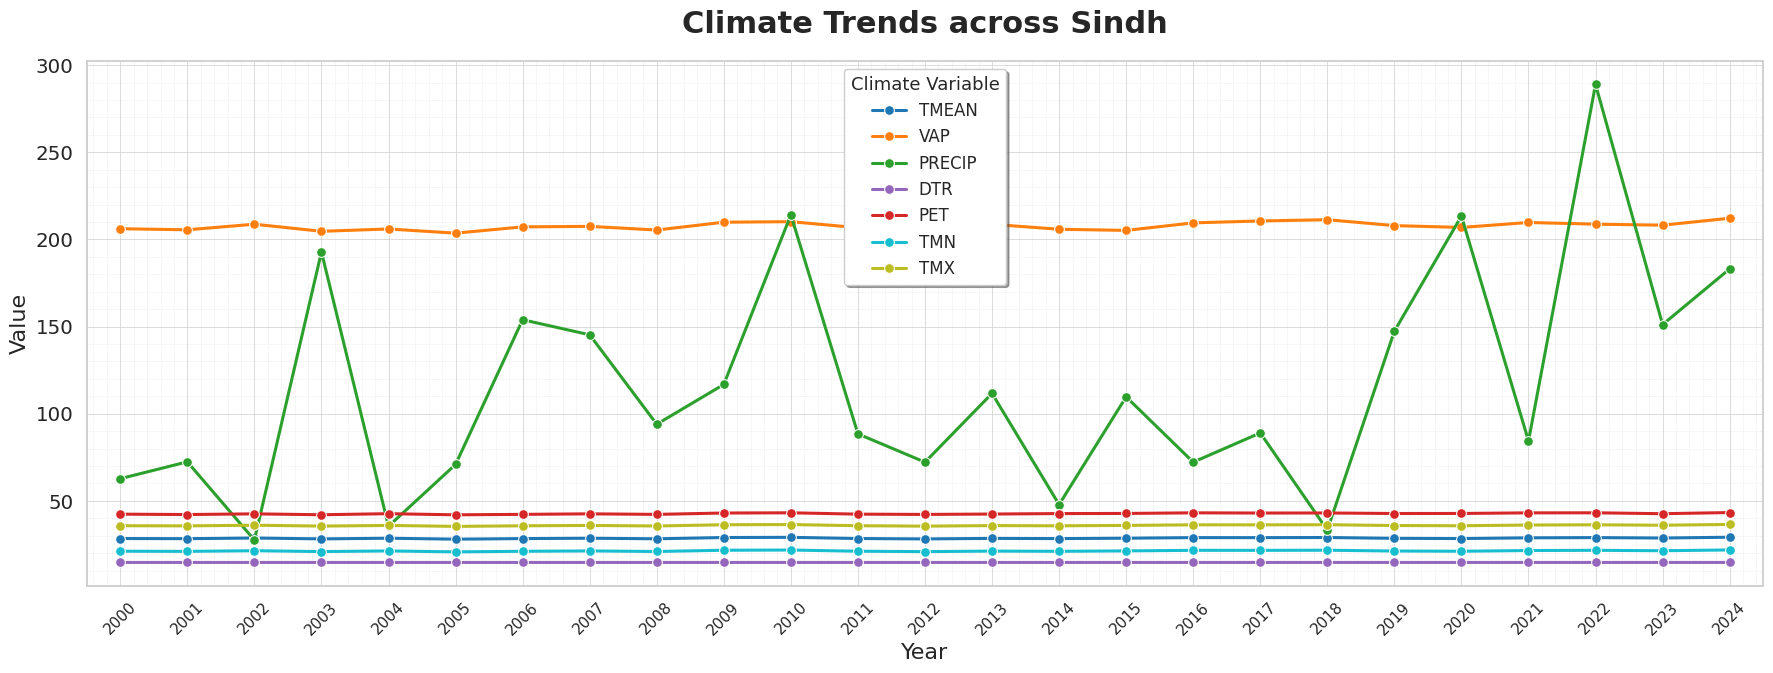

In [16]:
# Climate Trends across Sindh
climate_cols = [c for c in ["TMEAN", "VAP", "PRECIP", "DTR", "PET", "TMN", "TMX"] if c in plot_df.columns]

sindh_climate = (
    plot_df.groupby("YEAR")[climate_cols]
    .mean()
    .reset_index()
)

sindh_long = sindh_climate.melt(
    id_vars="YEAR",
    value_vars=climate_cols,
    var_name="CLIMATE_VARIABLE",
    value_name="VALUE"
)

plt.figure(figsize=(18, 7))

sns.lineplot(
    x="YEAR",
    y="VALUE",
    hue="CLIMATE_VARIABLE",
    data=sindh_long,
    marker="o",
    linewidth=2.2,
    markersize=7,
    palette={k: v for k, v in climate_palette.items() if k in climate_cols}
)

plt.title("Climate Trends across Sindh", fontsize=22, pad=20, weight="bold")
plt.xlabel("Year", fontsize=16)
plt.ylabel("Value", fontsize=16)

years = np.arange(plot_df["YEAR"].min(), plot_df["YEAR"].max() + 2, 1)
plt.xticks(years, rotation=45, fontsize=11)

plt.grid(which="major", linestyle="-", linewidth=0.7, alpha=0.7)
plt.grid(which="minor", linestyle="--", linewidth=0.4, alpha=0.4)
plt.minorticks_on()
plt.xlim(plot_df["YEAR"].min() - 0.5, plot_df["YEAR"].max() + 0.5)

plt.legend(
    title="Climate Variable",
    fontsize=12,
    title_fontsize=13,
    frameon=True,
    fancybox=True,
    shadow=True,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.00)
)

save_reference_plot("sindh_climate_trends.png")

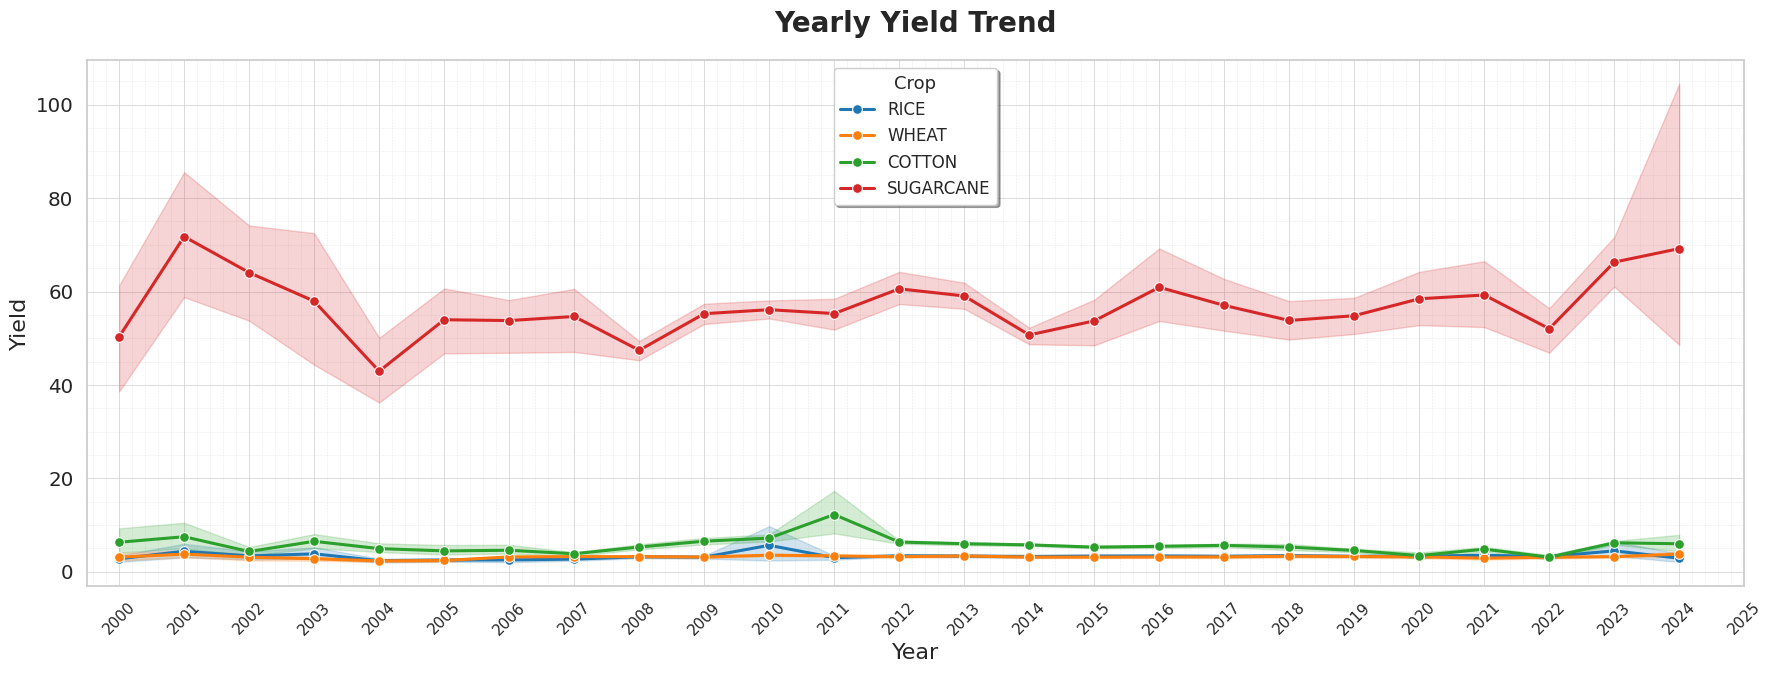

In [17]:
# Yearly Yield Trend
plt.figure(figsize=(18, 7))

sns.lineplot(
    x="YEAR",
    y="YIELD",
    hue="CROP",
    data=plot_df,
    marker="o",
    linewidth=2.2,
    markersize=7,
    palette=crop_colors_line
)

plt.title("Yearly Yield Trend", fontsize=20, weight="bold", pad=20)
plt.xlabel("Year", fontsize=16)
plt.ylabel("Yield", fontsize=16)

years = np.arange(plot_df["YEAR"].min(), plot_df["YEAR"].max() + 2)
plt.xticks(years, rotation=45, fontsize=11)

plt.grid(which="major", linestyle="-", linewidth=0.7, alpha=0.7)
plt.grid(which="minor", linestyle="--", linewidth=0.4, alpha=0.4)
plt.minorticks_on()
plt.xlim(plot_df["YEAR"].min() - 0.5, plot_df["YEAR"].max() + 1)

plt.legend(
    title="Crop",
    fontsize=12,
    title_fontsize=13,
    frameon=True,
    fancybox=True,
    shadow=True,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.00)
)

save_reference_plot("yearly_yield_trend.png")

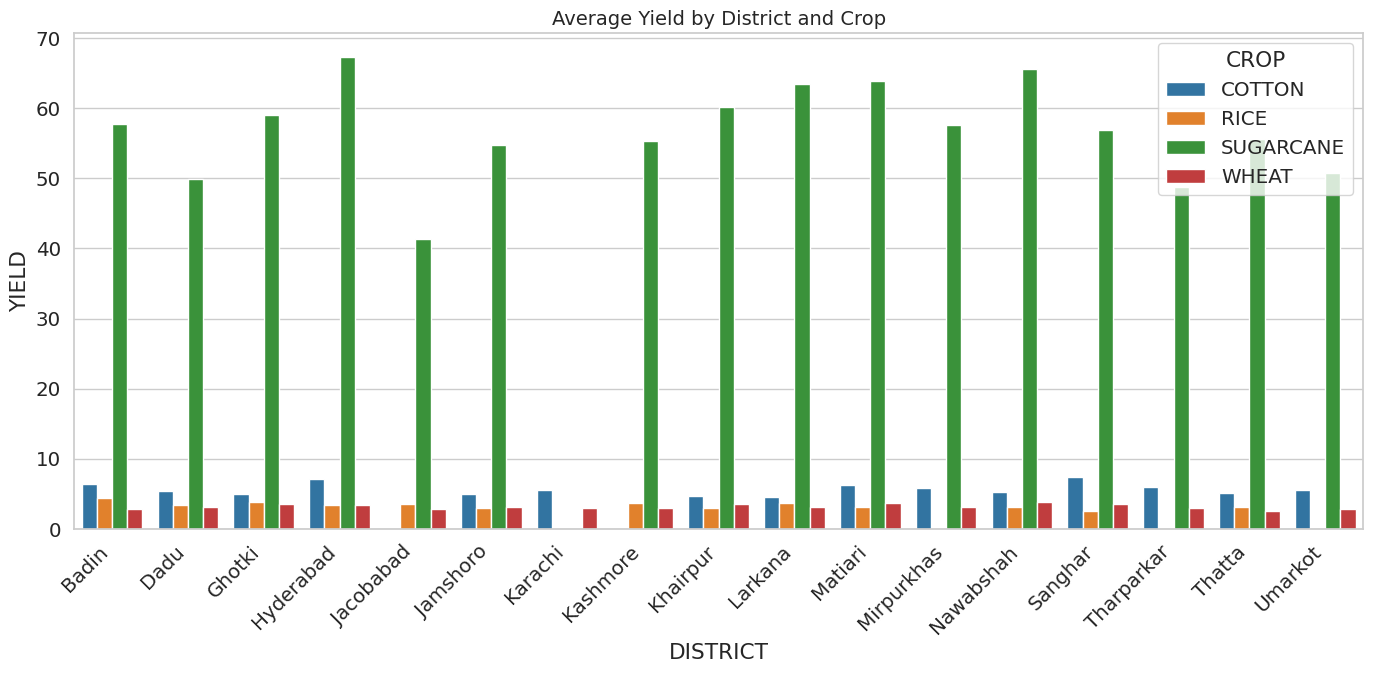

In [18]:
# Average Yield by District and Crop
avg_yield_district_crop = (
    plot_df
    .groupby(["DISTRICT", "CROP"], as_index=False)["YIELD"]
    .mean()
)

plt.figure(figsize=(14, 7))

sns.barplot(
    data=avg_yield_district_crop,
    x="DISTRICT",
    y="YIELD",
    hue="CROP",
    hue_order=["COTTON", "RICE", "SUGARCANE", "WHEAT"],
    palette={
        "COTTON": "#1f77b4",
        "RICE": "#ff7f0e",
        "SUGARCANE": "#2ca02c",
        "WHEAT": "#d62728",
    }
)

plt.title("Average Yield by District and Crop", fontsize=14)
plt.xlabel("DISTRICT")
plt.ylabel("YIELD")
plt.xticks(rotation=45, ha="right")
plt.legend(title="CROP", frameon=True)

save_reference_plot("average_yield_by_district_and_crop.png")

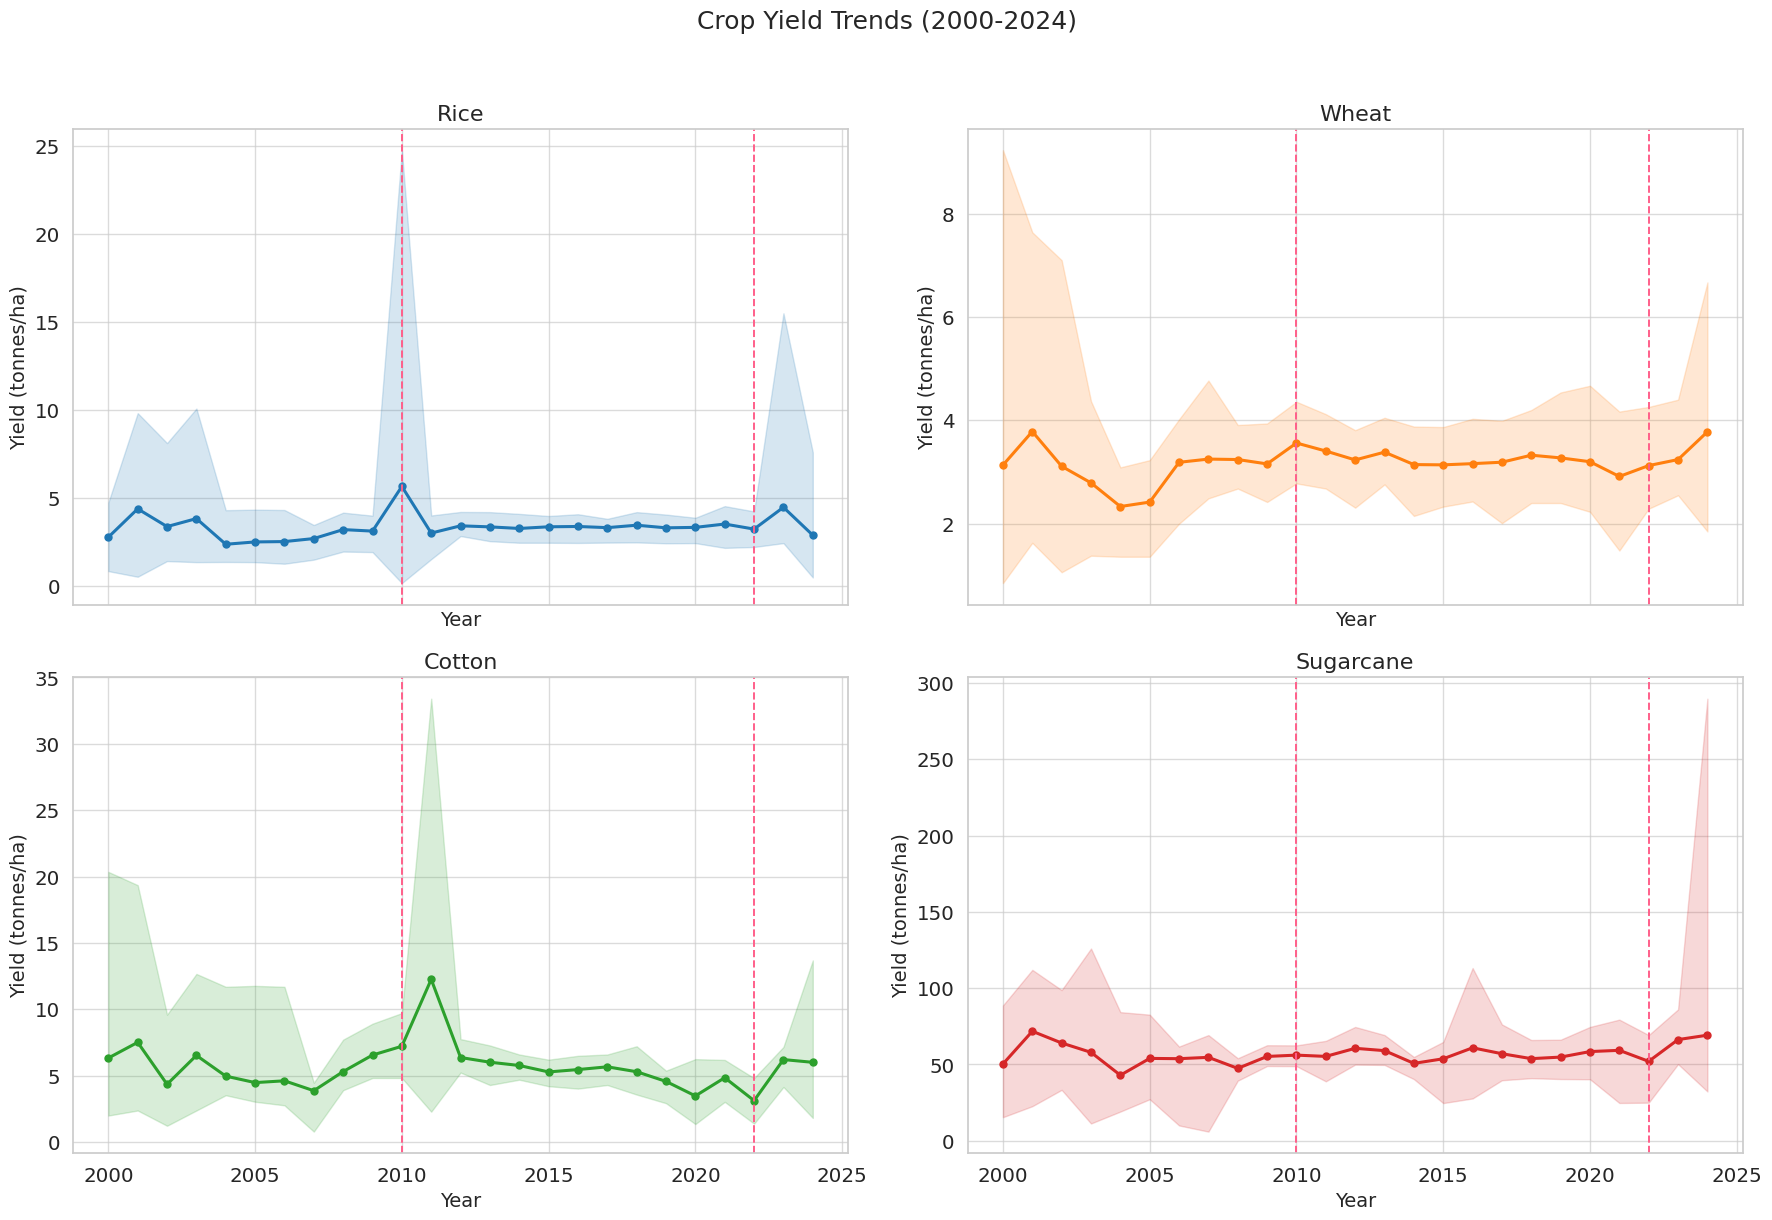

In [19]:
# Crop Yield Trends (2000-2024)
crop_order = ["RICE", "WHEAT", "COTTON", "SUGARCANE"]

yield_summary = (
    plot_df.groupby(["CROP", "YEAR"])["YIELD"]
    .agg(mean="mean", min="min", max="max")
    .reset_index()
)

fig, axes = plt.subplots(2, 2, figsize=(18, 12), sharex=True)
axes = axes.ravel()

for ax, crop in zip(axes, crop_order):
    d = yield_summary[yield_summary["CROP"] == crop].sort_values("YEAR")
    color = crop_colors_line[crop]

    ax.fill_between(d["YEAR"].to_numpy(), d["min"].to_numpy(), d["max"].to_numpy(), color=color, alpha=0.18)
    ax.plot(d["YEAR"], d["mean"], color=color, marker="o", linewidth=2.2, markersize=5)

    for year in [2010, 2022]:
        ax.axvline(year, color="#ff5f8a", linestyle="--", linewidth=1.4)

    ax.set_title(crop.capitalize(), fontsize=16)
    ax.set_xlabel("Year", fontsize=14)
    ax.set_ylabel("Yield (tonnes/ha)", fontsize=14)
    ax.grid(True, alpha=0.7)

fig.suptitle("Crop Yield Trends (2000-2024)", fontsize=18, y=1.02)
save_reference_plot("plot01_yield_trends.png")

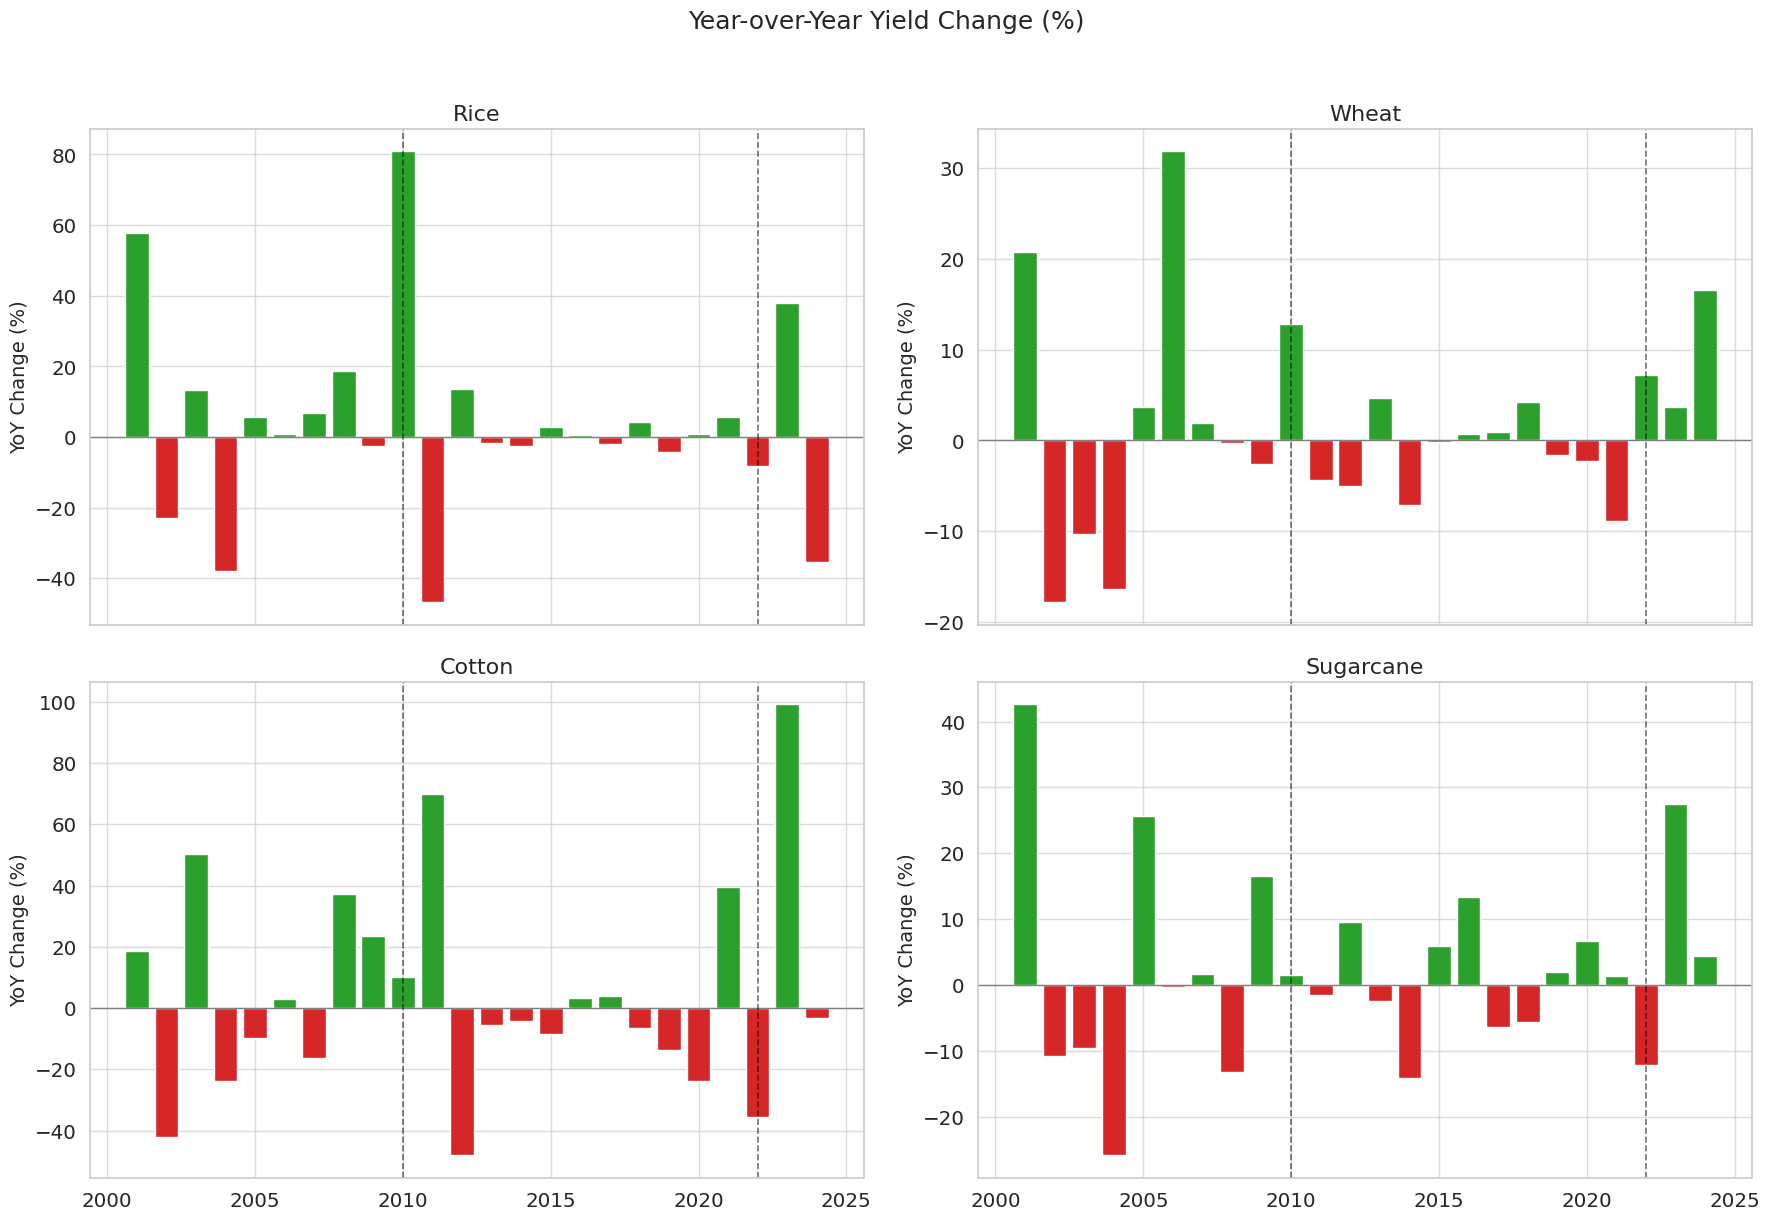

In [20]:
# Year-over-Year Yield Change (%)
yoy_df = yield_summary[["CROP", "YEAR", "mean"]].copy().sort_values(["CROP", "YEAR"])
yoy_df["YOY_CHANGE"] = yoy_df.groupby("CROP")["mean"].pct_change() * 100

fig, axes = plt.subplots(2, 2, figsize=(18, 12), sharex=True)
axes = axes.ravel()

for ax, crop in zip(axes, crop_order):
    d = yoy_df[(yoy_df["CROP"] == crop) & yoy_df["YOY_CHANGE"].notna()]
    colors = np.where(d["YOY_CHANGE"] >= 0, "#2ca02c", "#d62728")

    ax.bar(d["YEAR"], d["YOY_CHANGE"], color=colors, width=0.8)
    ax.axhline(0, color="gray", linewidth=1)

    for year in [2010, 2022]:
        ax.axvline(year, color="black", linestyle="--", linewidth=1.2, alpha=0.55)

    ax.set_title(crop.capitalize(), fontsize=16)
    ax.set_ylabel("YoY Change (%)", fontsize=14)
    ax.grid(True, alpha=0.7)

fig.suptitle("Year-over-Year Yield Change (%)", fontsize=18, y=1.02)
save_reference_plot("plot05_yoy_yield_change.png")

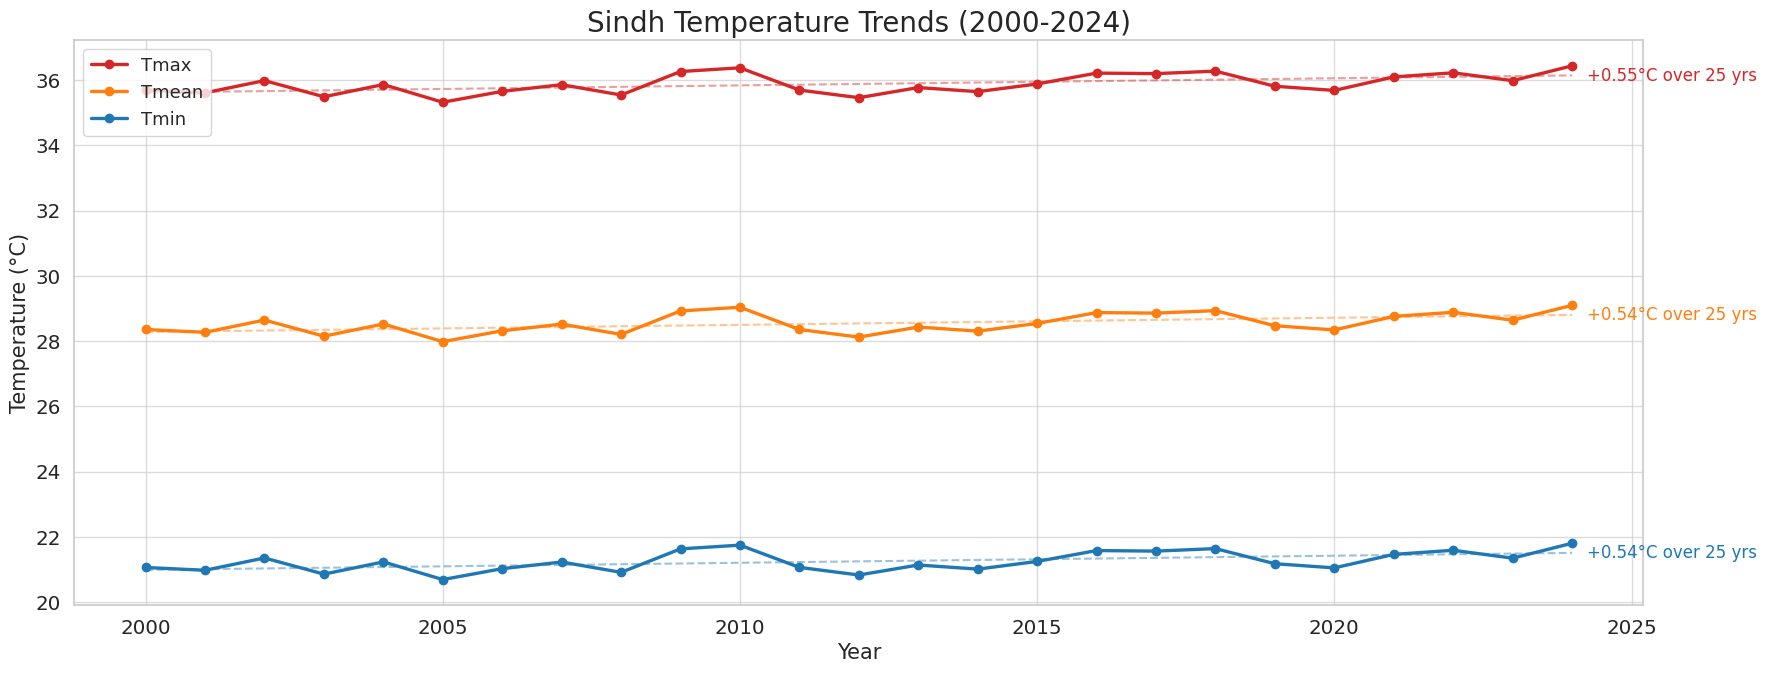

In [21]:
# Sindh Temperature Trends (2000-2024)
temp_cols = [c for c in ["TMX", "TMEAN", "TMN"] if c in plot_df.columns]
temp_year = plot_df.groupby("YEAR")[temp_cols].mean().reset_index()

temp_specs = [
    ("TMX", "Tmax", "#d62728"),
    ("TMEAN", "Tmean", "#ff7f0e"),
    ("TMN", "Tmin", "#1f77b4"),
]

plt.figure(figsize=(18, 7))
ax = plt.gca()

for col, label, color in temp_specs:
    if col not in temp_year.columns:
        continue

    ax.plot(temp_year["YEAR"], temp_year[col], marker="o", linewidth=2.4, markersize=6, color=color, label=label)
    z = np.polyfit(temp_year["YEAR"], temp_year[col], 1)
    trend = np.poly1d(z)(temp_year["YEAR"])
    ax.plot(temp_year["YEAR"], trend, linestyle="--", color=color, alpha=0.45, linewidth=1.5)

    change = z[0] * len(temp_year)
    ax.text(temp_year["YEAR"].max() + 0.25, trend[-1], f"+{change:.2f}°C over {len(temp_year)} yrs", color=color, va="center", fontsize=12)

plt.title("Sindh Temperature Trends (2000-2024)", fontsize=20)
plt.xlabel("Year", fontsize=15)
plt.ylabel("Temperature (°C)", fontsize=15)
plt.xlim(plot_df["YEAR"].min() - 1.2, plot_df["YEAR"].max() + 1.2)
plt.legend(loc="upper left", frameon=True, fontsize=13)
plt.grid(True, alpha=0.7)

save_reference_plot("plot06_temperature_trends.png")

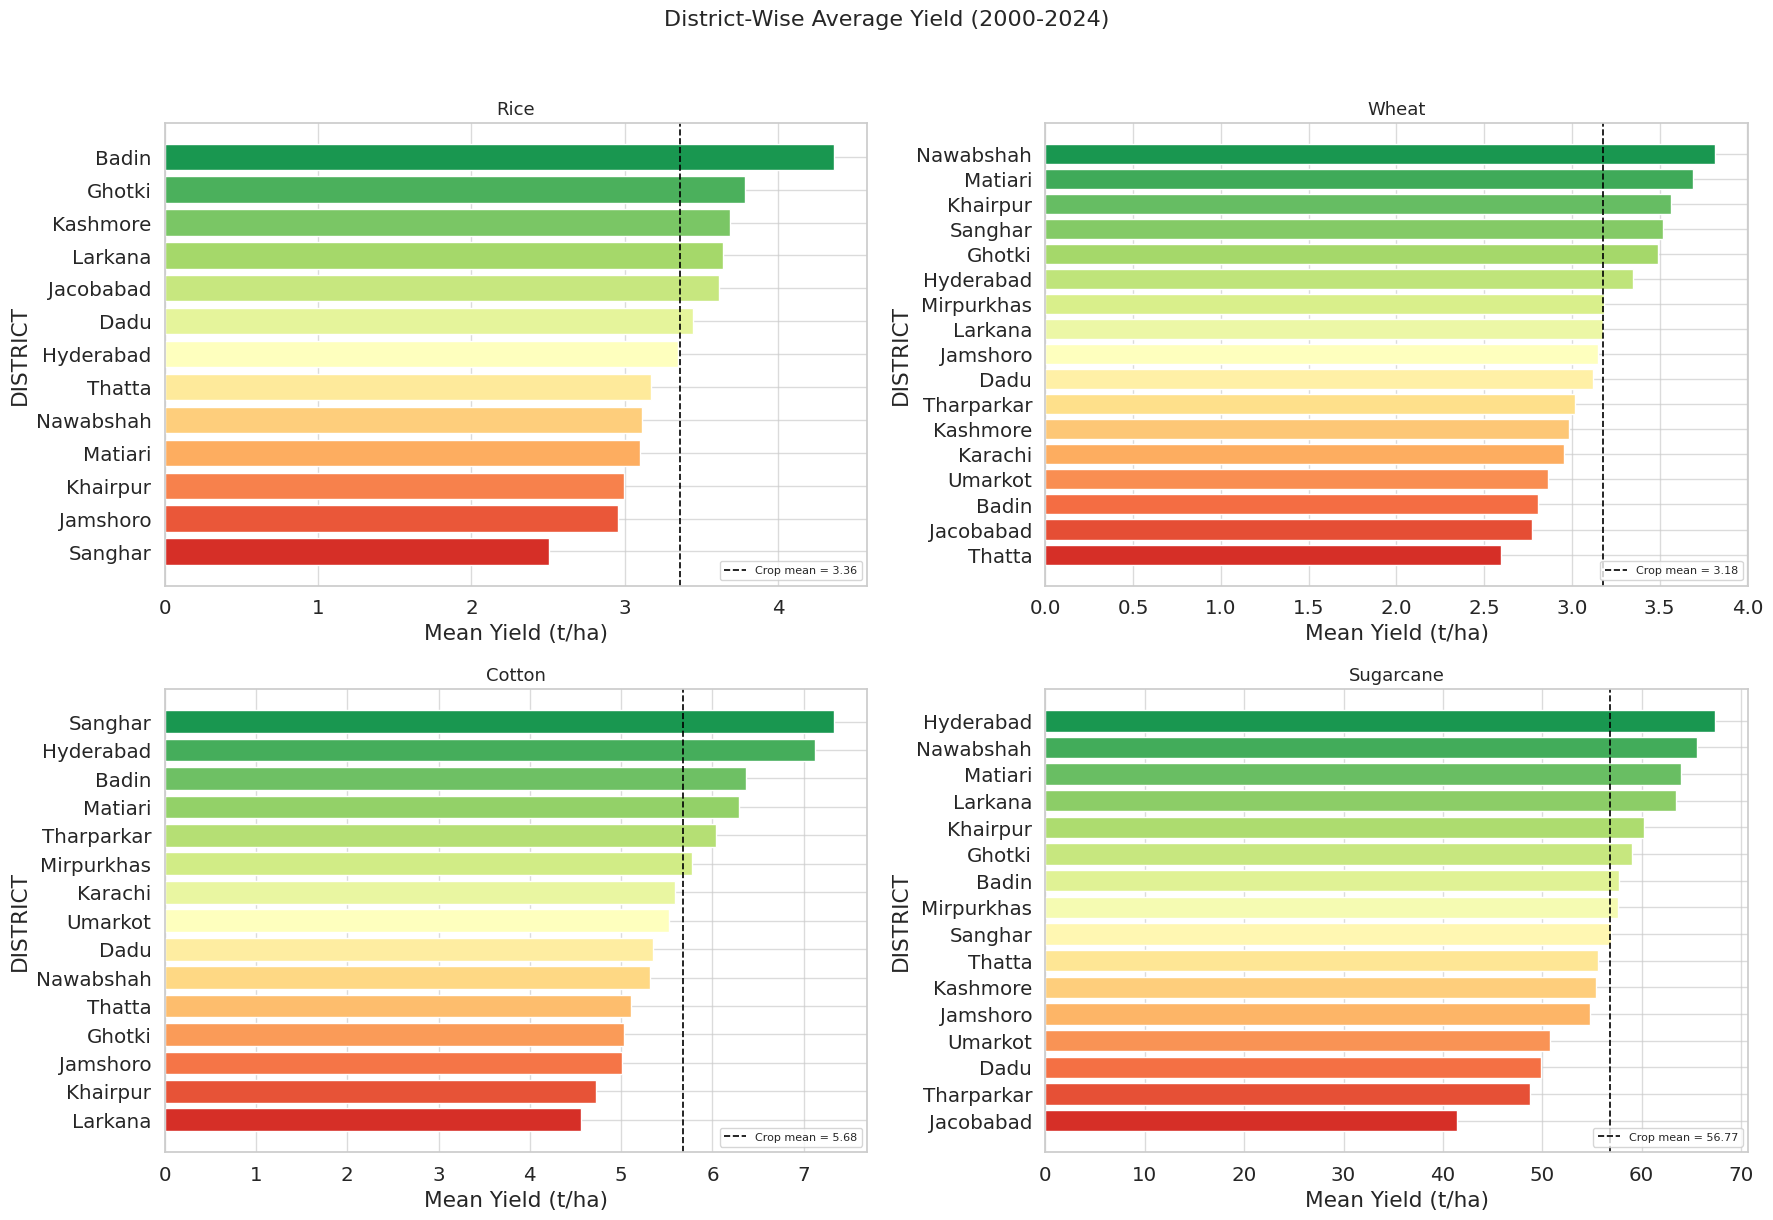

In [22]:
# District-Wise Average Yield (2000-2024)
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.ravel()

for ax, crop in zip(axes, crop_order):
    d = (
        plot_df[plot_df["CROP"] == crop]
        .groupby("DISTRICT")["YIELD"]
        .mean()
        .sort_values(ascending=False)
    )

    colors = plt.cm.RdYlGn(np.linspace(0.9, 0.1, len(d)))
    ax.barh(d.index, d.values, color=colors)
    ax.invert_yaxis()

    mean_val = d.mean()
    ax.axvline(mean_val, color="black", linestyle="--", linewidth=1.2, label=f"Crop mean = {mean_val:.2f}")

    ax.set_title(crop.capitalize(), fontsize=13)
    ax.set_xlabel("Mean Yield (t/ha)")
    ax.set_ylabel("DISTRICT")
    ax.legend(loc="lower right", fontsize=8, frameon=True)
    ax.grid(True, alpha=0.7)

fig.suptitle("District-Wise Average Yield (2000-2024)", fontsize=16, y=1.02)
save_reference_plot("plot15_district_yield_ranked.png")

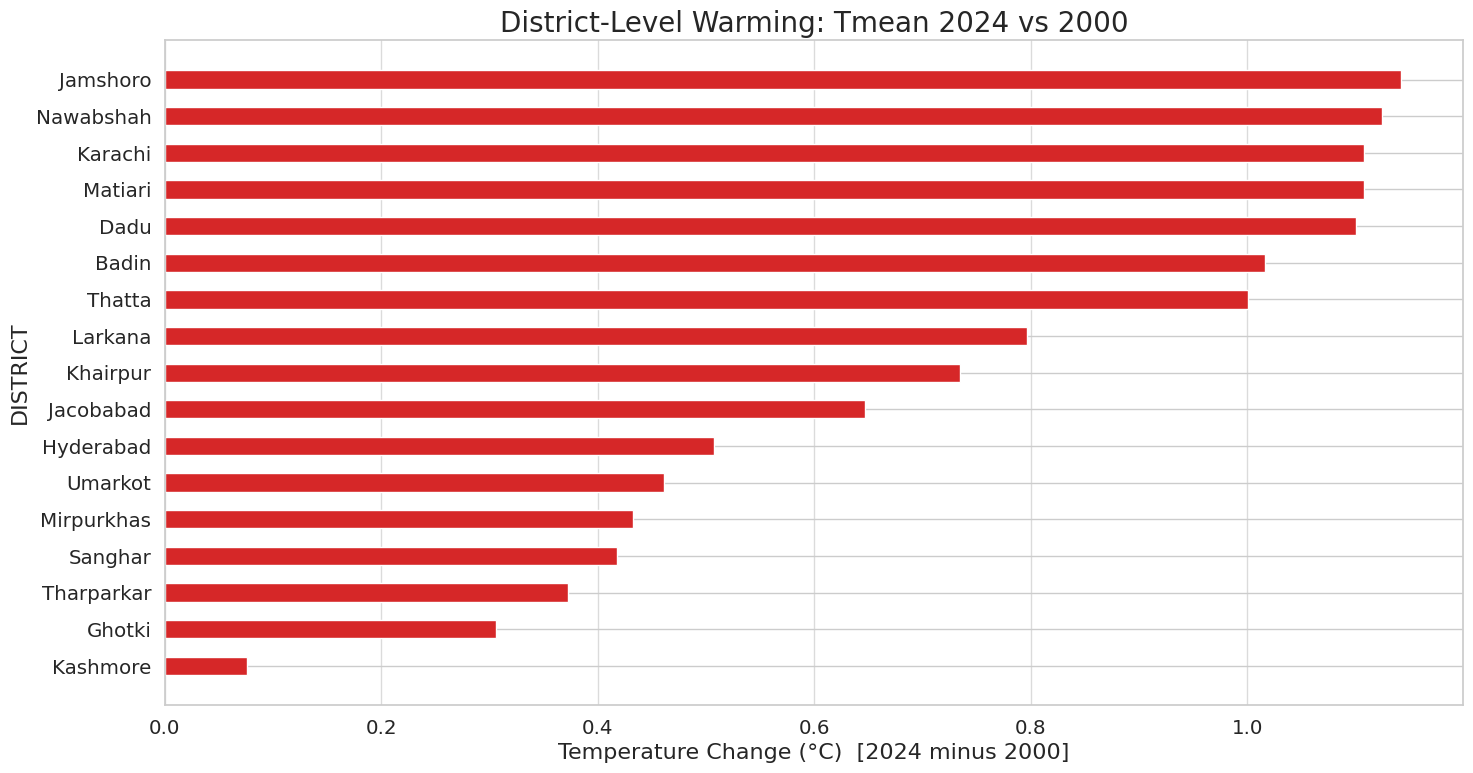

In [23]:
# District-Level Warming: Tmean 2024 vs 2000
if "TMEAN" in plot_df.columns:
    district_temp = plot_df.groupby(["DISTRICT", "YEAR"])["TMEAN"].mean().unstack()
    first_year = int(plot_df["YEAR"].min())
    last_year = int(plot_df["YEAR"].max())

    warming = (district_temp[last_year] - district_temp[first_year]).sort_values(ascending=False)

    plt.figure(figsize=(15, 8))
    plt.barh(warming.index, warming.values, color="#d62728", height=0.5)
    plt.gca().invert_yaxis()

    plt.title(f"District-Level Warming: Tmean {last_year} vs {first_year}", fontsize=20)
    plt.xlabel(f"Temperature Change (°C)  [{last_year} minus {first_year}]", fontsize=16)
    plt.ylabel("DISTRICT", fontsize=16)
    plt.grid(True, axis="x", alpha=0.7)

    save_reference_plot("plot16_district_warming.png")
else:
    print("Skipping district warming plot because TMEAN is unavailable.")

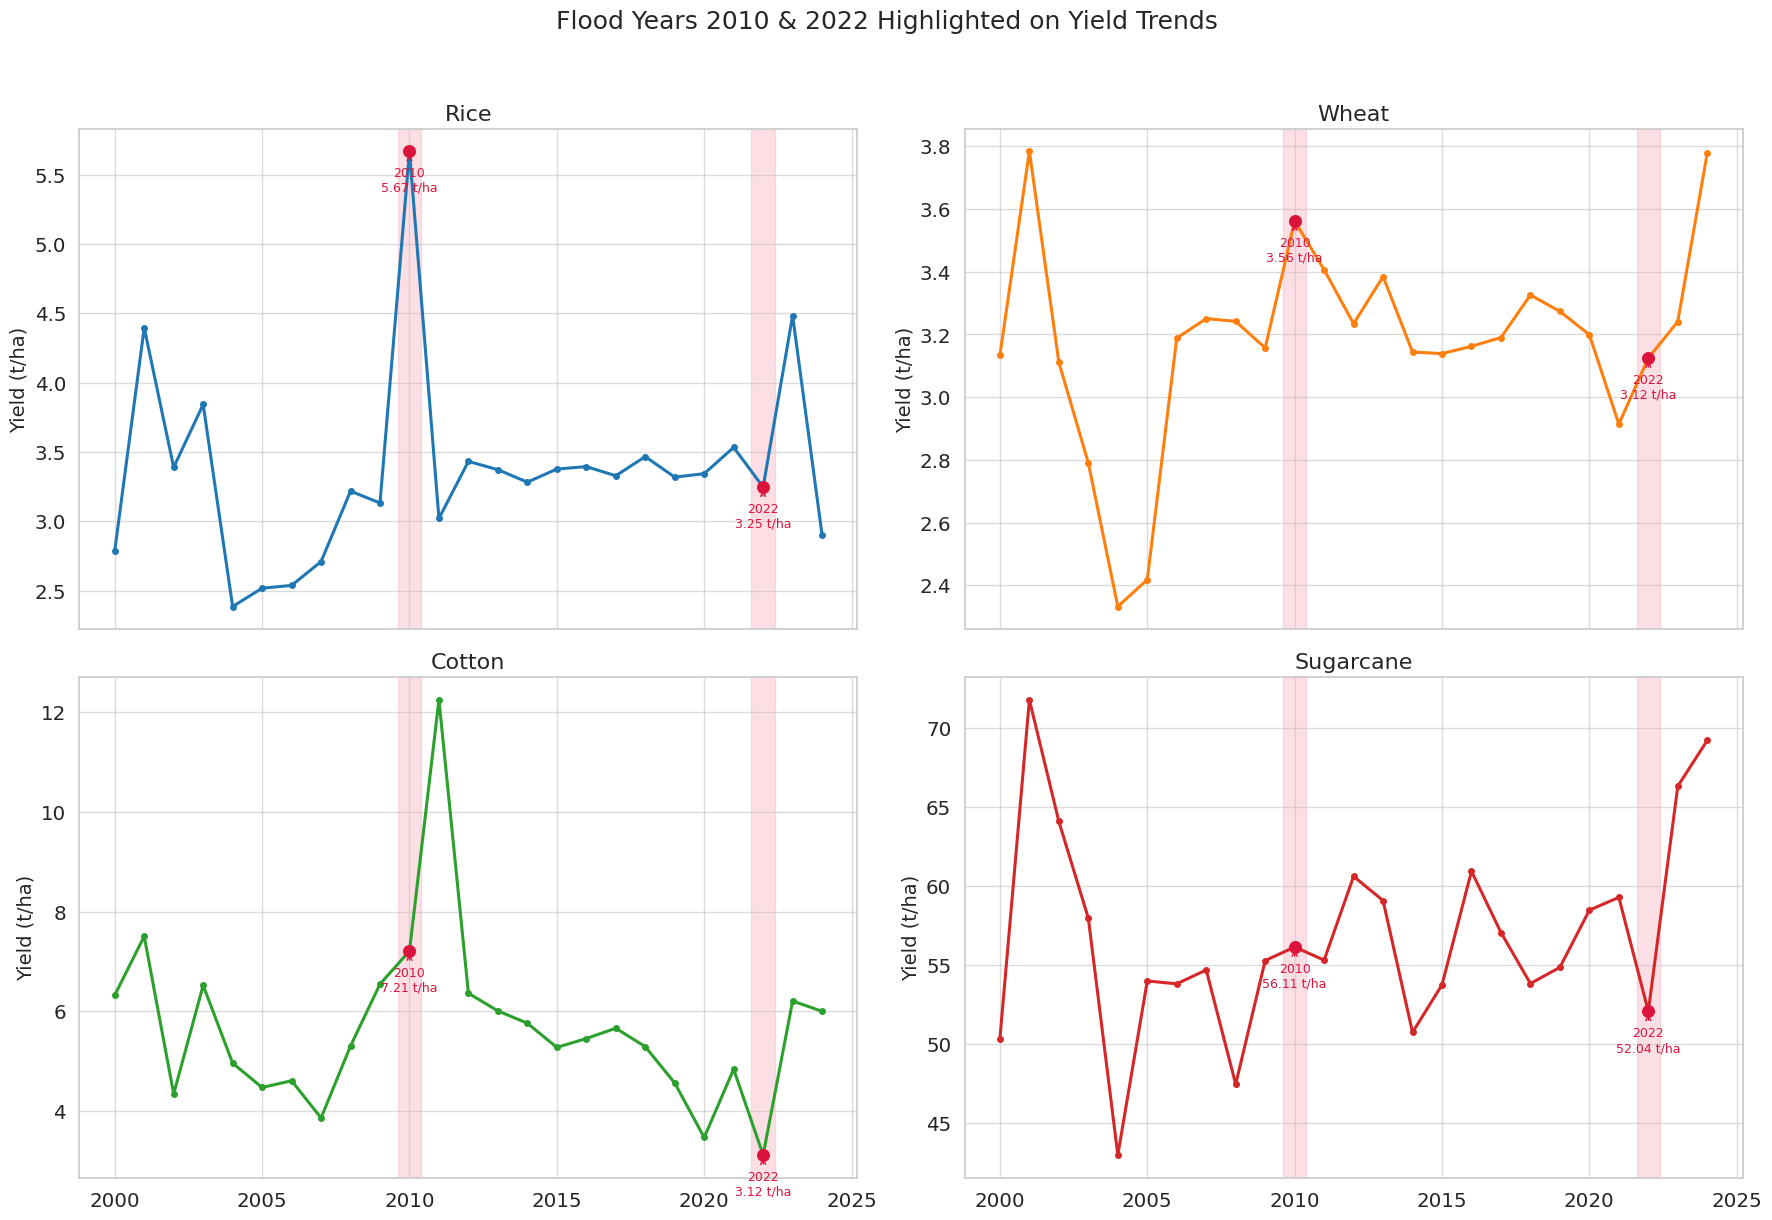

In [24]:
# Flood Years 2010 & 2022 Highlighted on Yield Trends
fig, axes = plt.subplots(2, 2, figsize=(18, 12), sharex=True)
axes = axes.ravel()

for ax, crop in zip(axes, crop_order):
    d = yield_summary[yield_summary["CROP"] == crop].sort_values("YEAR")
    color = crop_colors_line[crop]

    ax.plot(d["YEAR"], d["mean"], color=color, marker="o", linewidth=2.2, markersize=4)

    for year in [2010, 2022]:
        ax.axvspan(year - 0.4, year + 0.4, color="#f4a6b7", alpha=0.35)
        row = d[d["YEAR"] == year]
        if not row.empty:
            y = float(row["mean"].iloc[0])
            ax.scatter([year], [y], s=70, color="crimson", zorder=5)
            ax.annotate(
                f"{year}\n{y:.2f} t/ha",
                xy=(year, y),
                xytext=(year, y - (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.08),
                color="crimson",
                ha="center",
                fontsize=9,
                arrowprops=dict(arrowstyle="->", color="crimson", lw=1),
            )

    ax.set_title(crop.capitalize(), fontsize=16)
    ax.set_ylabel("Yield (t/ha)", fontsize=14)
    ax.grid(True, alpha=0.7)

fig.suptitle("Flood Years 2010 & 2022 Highlighted on Yield Trends", fontsize=18, y=1.02)
save_reference_plot("plot18_flood_year_yield_highlight.png")

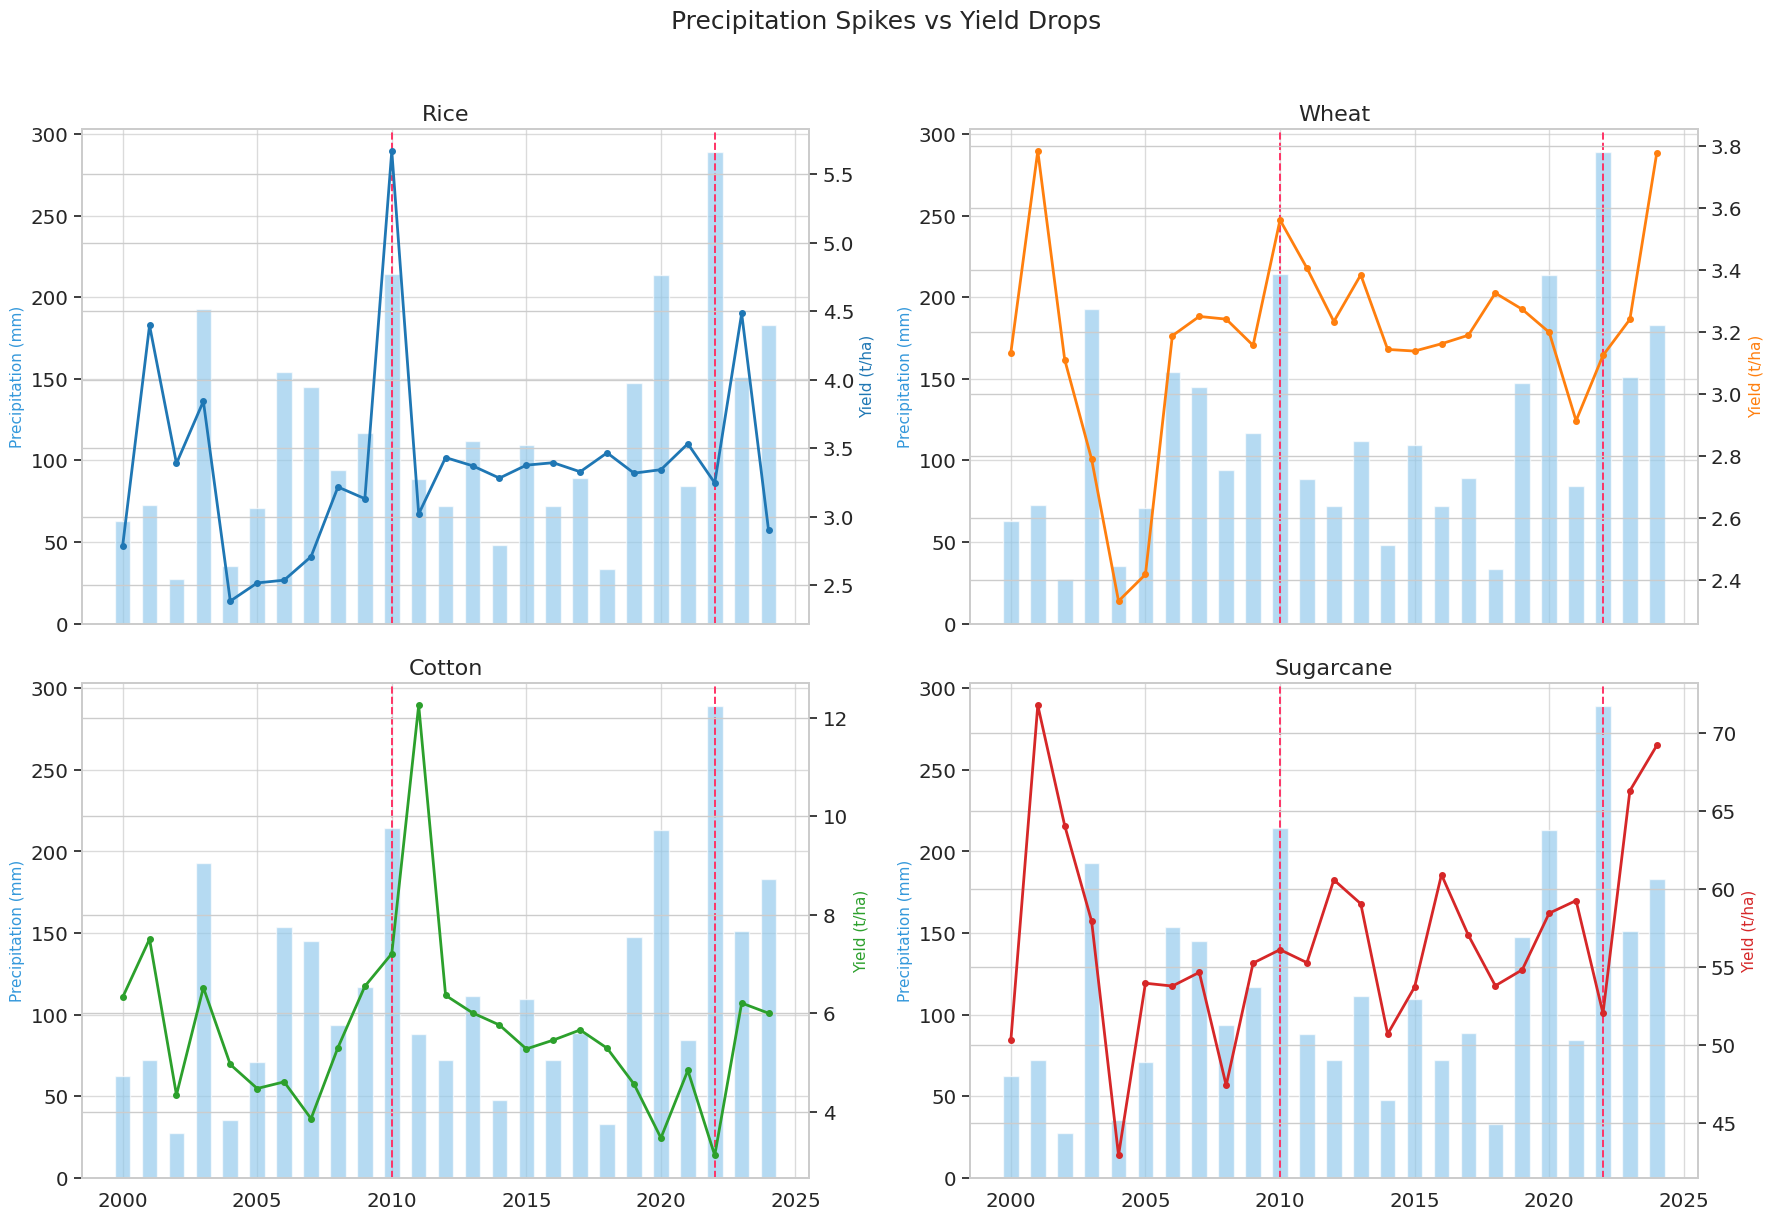

In [25]:
# Precipitation Spikes vs Yield Drops
if "PRECIP" in plot_df.columns:
    precip_year = plot_df.groupby("YEAR")["PRECIP"].mean().reset_index()

    fig, axes = plt.subplots(2, 2, figsize=(18, 12), sharex=True)
    axes = axes.ravel()

    for ax, crop in zip(axes, crop_order):
        d = yield_summary[yield_summary["CROP"] == crop].sort_values("YEAR")
        color = crop_colors_line[crop]

        ax.bar(precip_year["YEAR"], precip_year["PRECIP"], color="#8ec7eb", alpha=0.65, width=0.58)
        ax.set_ylabel("Precipitation (mm)", color="#3498db", fontsize=11)

        ax2 = ax.twinx()
        ax2.plot(d["YEAR"], d["mean"], color=color, marker="o", linewidth=2.0, markersize=4)
        ax2.set_ylabel("Yield (t/ha)", color=color, fontsize=11)

        for year in [2010, 2022]:
            ax.axvline(year, color="#ff3366", linestyle="--", linewidth=1.4)

        ax.set_title(crop.capitalize(), fontsize=16)
        ax.grid(True, alpha=0.7)

    fig.suptitle("Precipitation Spikes vs Yield Drops", fontsize=18, y=1.02)
    save_reference_plot("plot19_precip_spikes_vs_yield.png")
else:
    print("Skipping precipitation spike plot because PRECIP is unavailable.")

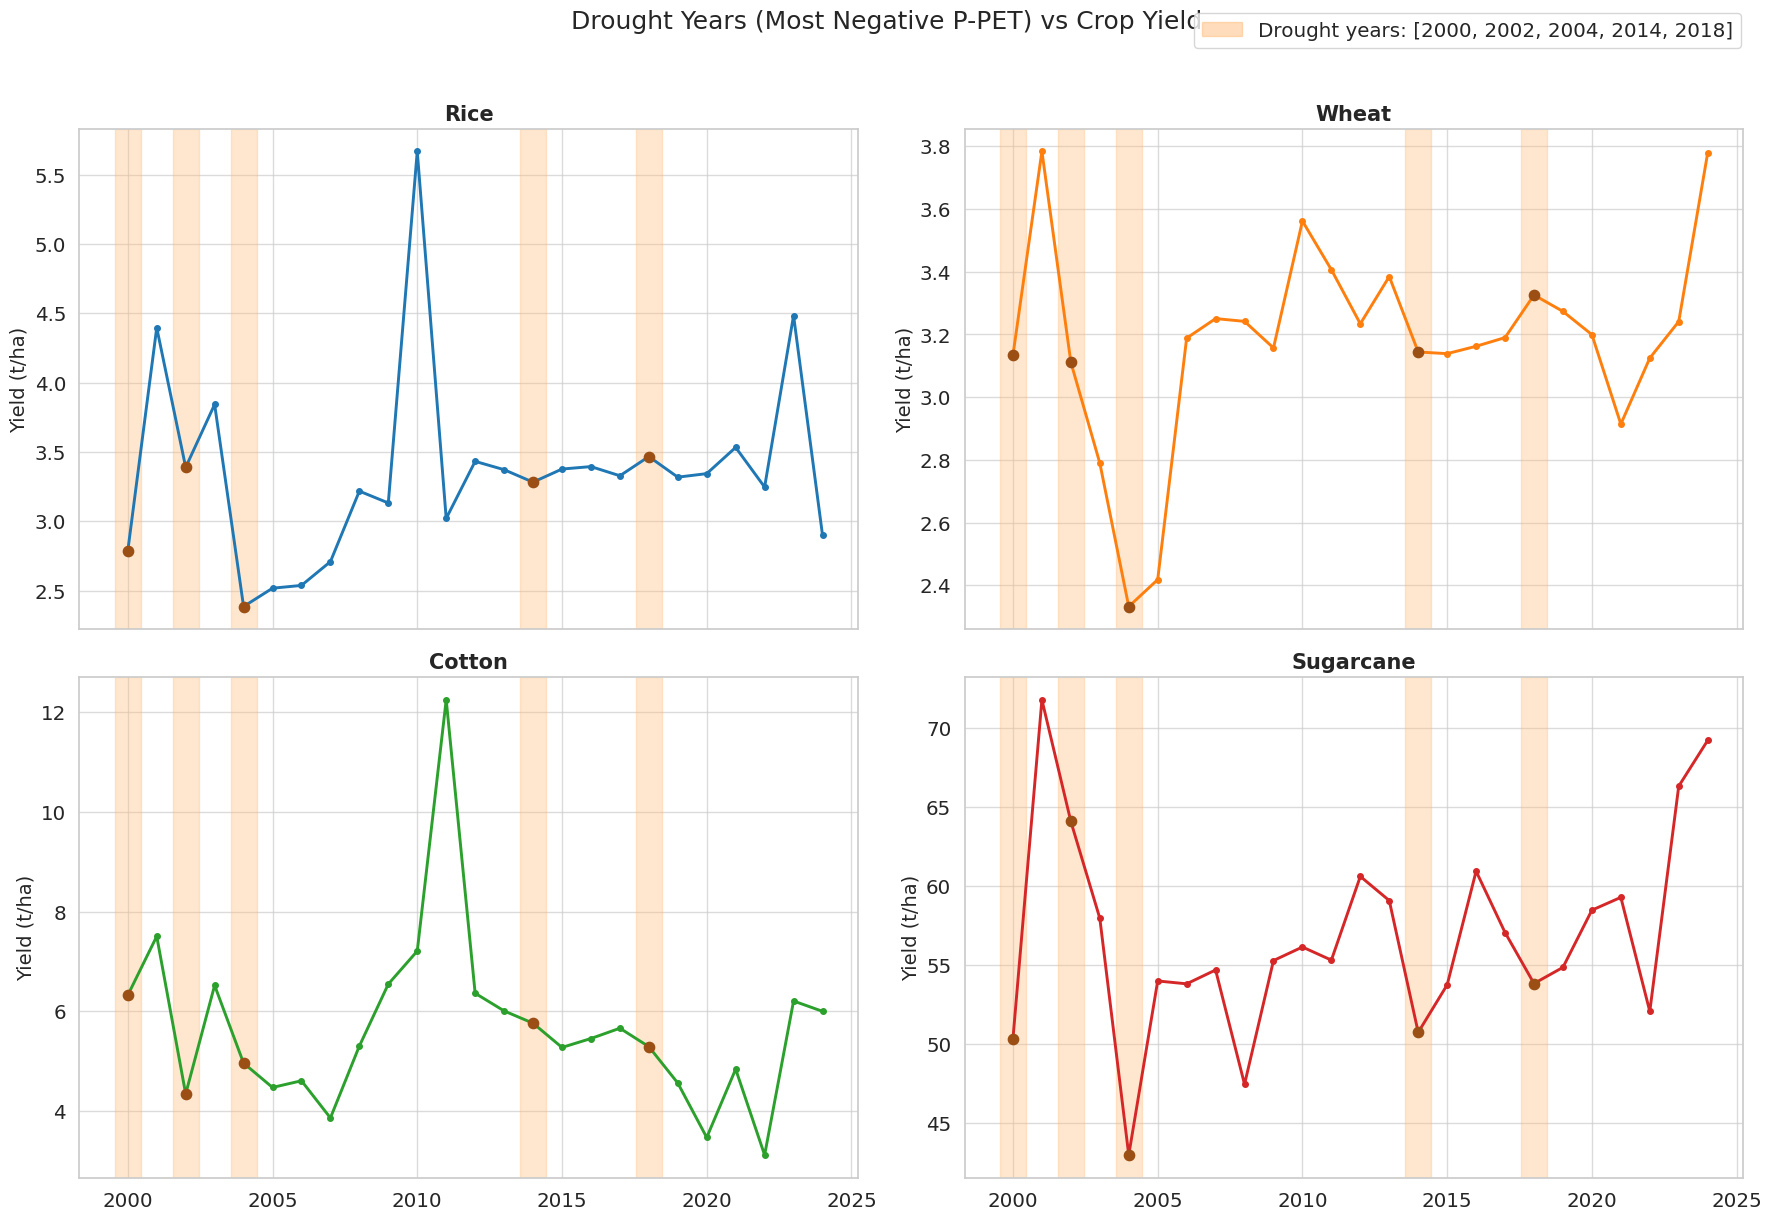

In [26]:
# Drought Years (Most Negative P-PET) vs Crop Yield
if "P_MINUS_PET" not in plot_df.columns and {"PRECIP", "PET"}.issubset(plot_df.columns):
    plot_df["P_MINUS_PET"] = plot_df["PRECIP"] - plot_df["PET"]

if "P_MINUS_PET" in plot_df.columns:
    drought_years = (
        plot_df.groupby("YEAR")["P_MINUS_PET"]
        .mean()
        .nsmallest(5)
        .index.astype(int)
        .sort_values()
        .tolist()
    )

    fig, axes = plt.subplots(2, 2, figsize=(18, 12), sharex=True)
    axes = axes.ravel()

    for ax, crop in zip(axes, crop_order):
        d = yield_summary[yield_summary["CROP"] == crop].sort_values("YEAR")
        color = crop_colors_line[crop]

        ax.plot(d["YEAR"], d["mean"], color=color, marker="o", linewidth=2.1, markersize=4)

        for year in drought_years:
            ax.axvspan(year - 0.45, year + 0.45, color="#ffbb78", alpha=0.35)
            row = d[d["YEAR"] == year]
            if not row.empty:
                ax.scatter([year], [float(row["mean"].iloc[0])], color="#9c4f14", s=55, zorder=5)

        ax.set_title(crop.capitalize(), fontsize=15, weight="bold")
        ax.set_ylabel("Yield (t/ha)", fontsize=14)
        ax.grid(True, alpha=0.7)

    fig.suptitle("Drought Years (Most Negative P-PET) vs Crop Yield", fontsize=18, y=1.02)
    fig.legend(
        handles=[Patch(facecolor="#ffbb78", edgecolor="#ffbb78", alpha=0.5, label=f"Drought years: {drought_years}")],
        loc="upper right",
        bbox_to_anchor=(0.98, 1.025),
    )
    save_reference_plot("plot20_drought_years_vs_yield.png")
else:
    print("Skipping drought-years plot because P_MINUS_PET is unavailable.")

---
## Exploratory Data Analysis (EDA)

> **All EDA transforms are fit on the full dataset for visualisation only.**  
> The modelling pipeline re-fits every transformer on training data exclusively.


###Distribution & Skewness Profile

EDA years used for diagnostics and feature selection: 2000-2019


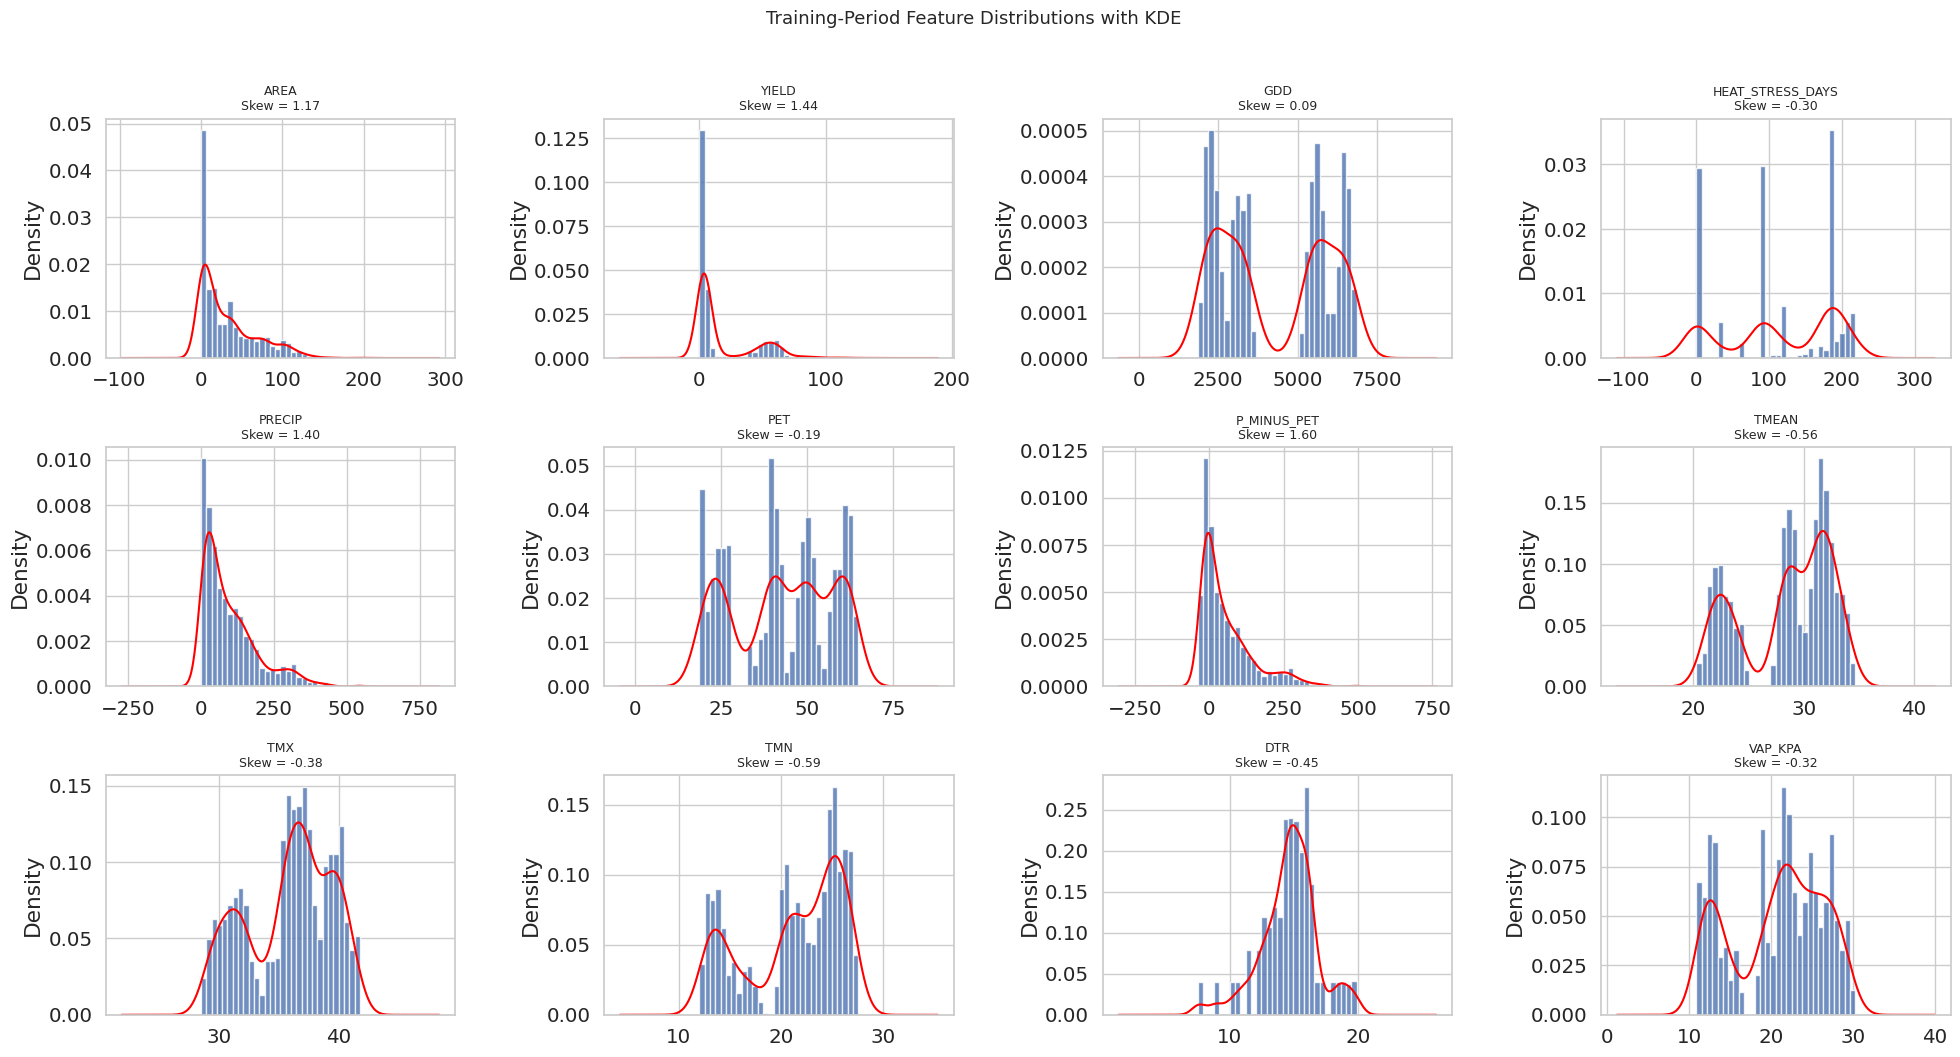

In [27]:
# Restrict all EDA-driven decisions to the pre-2020 training period only
eda_source_df = raw_df[raw_df["YEAR"] < FINAL_TEST_START].copy()
print(
    f"EDA years used for diagnostics and feature selection: "
    f"{eda_source_df['YEAR'].min()}-{eda_source_df['YEAR'].max()}"
)

_all_num_cols = [
    c for c in eda_source_df.select_dtypes(include="number").columns
    if c not in ["YEAR", "PRODUCTION"]
]

N_COLS = 4
N_ROWS = int(np.ceil(len(_all_num_cols) / N_COLS))

fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(20, N_ROWS * 3.5))
axes = axes.flatten()
for i, col in enumerate(_all_num_cols):
    axes[i].hist(
        eda_source_df[col].dropna(),
        bins=30,
        color="#4C72B0",
        edgecolor="white",
        alpha=0.8,
        density=True,
    )
    eda_source_df[col].dropna().plot(kind="kde", ax=axes[i], color="red", linewidth=1.5)
    axes[i].set_title(f"{col}\nSkew = {eda_source_df[col].skew():.2f}", fontsize=9)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Training-Period Feature Distributions with KDE", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_distributions.png", bbox_inches="tight", dpi=150)
plt.show()


In [28]:
# Skewness table - decides which columns need Yeo-Johnson (training period only)
skew_series = eda_source_df[_all_num_cols].skew()

def skew_tag(x):
    ax = abs(x)
    if ax > 1:
        return "HIGHLY SKEWED"
    elif ax > 0.5:
        return "Moderate"
    else:
        return "Symmetric"

skew_df = pd.DataFrame({
    "skewness": skew_series,
    "abs_skew": skew_series.abs(),
    "category": skew_series.apply(skew_tag),
}).sort_values("abs_skew", ascending=False)

print(skew_df.to_string())

EDA_TRANSFORM_COLS = skew_df[
    skew_df["category"].isin(["HIGHLY SKEWED", "Moderate"])
].index.tolist()
print(f"\nColumns queued for Yeo-Johnson (EDA, train years only): {EDA_TRANSFORM_COLS}")


                  skewness  abs_skew       category
P_MINUS_PET       1.595163  1.595163  HIGHLY SKEWED
YIELD             1.436458  1.436458  HIGHLY SKEWED
PRECIP            1.399165  1.399165  HIGHLY SKEWED
AREA              1.169395  1.169395  HIGHLY SKEWED
TMN              -0.587176  0.587176       Moderate
TMEAN            -0.556041  0.556041       Moderate
DTR              -0.452165  0.452165      Symmetric
TMX              -0.383518  0.383518      Symmetric
VAP_KPA          -0.321537  0.321537      Symmetric
HEAT_STRESS_DAYS -0.303578  0.303578      Symmetric
PET              -0.188200  0.188200      Symmetric
GDD               0.088040  0.088040      Symmetric

Columns queued for Yeo-Johnson (EDA, train years only): ['P_MINUS_PET', 'YIELD', 'PRECIP', 'AREA', 'TMN', 'TMEAN']


###Yeo-Johnson Transform — Before vs After

> `pt_eda` is fit on the full dataset for visualisation only.  
> The pipeline refits separate `PowerTransformer` instances on training data exclusively.


In [29]:
df_eda = eda_source_df.copy()

if EDA_TRANSFORM_COLS:
    pt_eda = PowerTransformer(method="yeo-johnson", standardize=False)
    df_eda[EDA_TRANSFORM_COLS] = pt_eda.fit_transform(df_eda[EDA_TRANSFORM_COLS])
    print("Post-transform skewness (training years only):")
    print(df_eda[EDA_TRANSFORM_COLS].skew().round(3).to_string())
else:
    print("No columns required transformation.")


Post-transform skewness (training years only):
P_MINUS_PET    0.078
YIELD          0.323
PRECIP        -0.062
AREA          -0.107
TMN           -0.287
TMEAN         -0.224


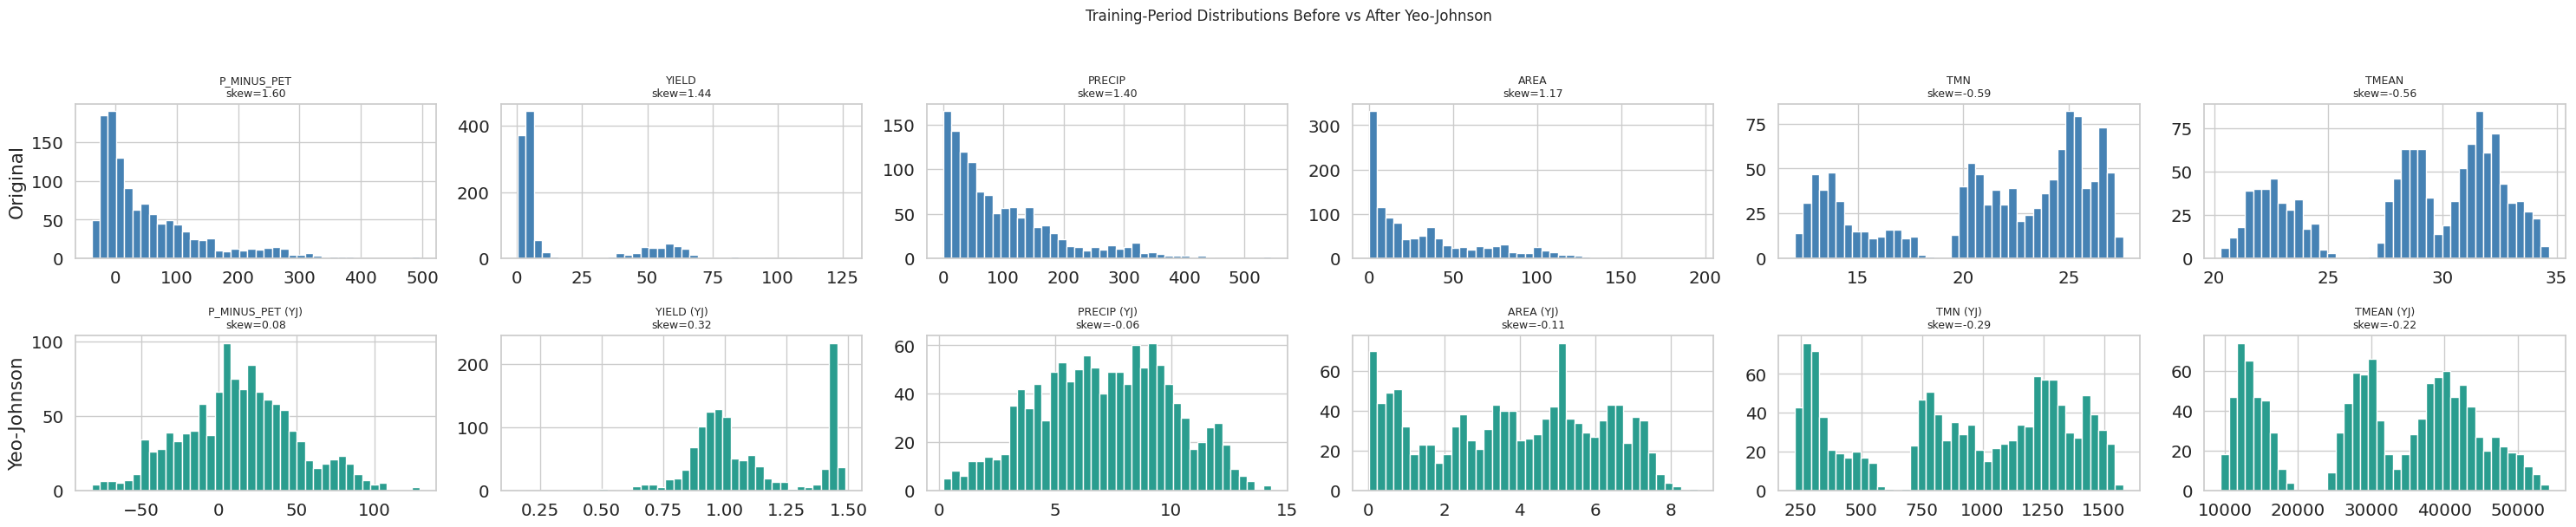

In [30]:
n_t = len(EDA_TRANSFORM_COLS)
if n_t > 0:
    fig, axes = plt.subplots(2, n_t, figsize=(5 * n_t, 6))
    if n_t == 1:
        axes = np.array([[axes[0]], [axes[1]]])
    for i, col in enumerate(EDA_TRANSFORM_COLS):
        axes[0, i].hist(eda_source_df[col], bins=40, color="steelblue", edgecolor="white")
        axes[0, i].set_title(f"{col}\nskew={eda_source_df[col].skew():.2f}", fontsize=9)
        axes[1, i].hist(df_eda[col], bins=40, color="#2A9D8F", edgecolor="white")
        axes[1, i].set_title(f"{col} (YJ)\nskew={df_eda[col].skew():.2f}", fontsize=9)
    axes[0, 0].set_ylabel("Original")
    axes[1, 0].set_ylabel("Yeo-Johnson")
    plt.suptitle("Training-Period Distributions Before vs After Yeo-Johnson", fontsize=12, y=1.02)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "eda_yeo_johnson.png", bbox_inches="tight", dpi=150)
    plt.show()


###Multicollinearity Analysis — Spearman Correlation + VIF

> High multicollinearity inflates variance in linear models and wastes capacity in tree models.  
> We use two complementary measures:
> - **Spearman |r| > 0.85** — pairwise rank correlation between features  
> - **VIF > 10** — variance inflation factor (how much a feature is explained by all others)  
>
> For each redundant pair we keep the more directly interpretable / agronomically meaningful variable.


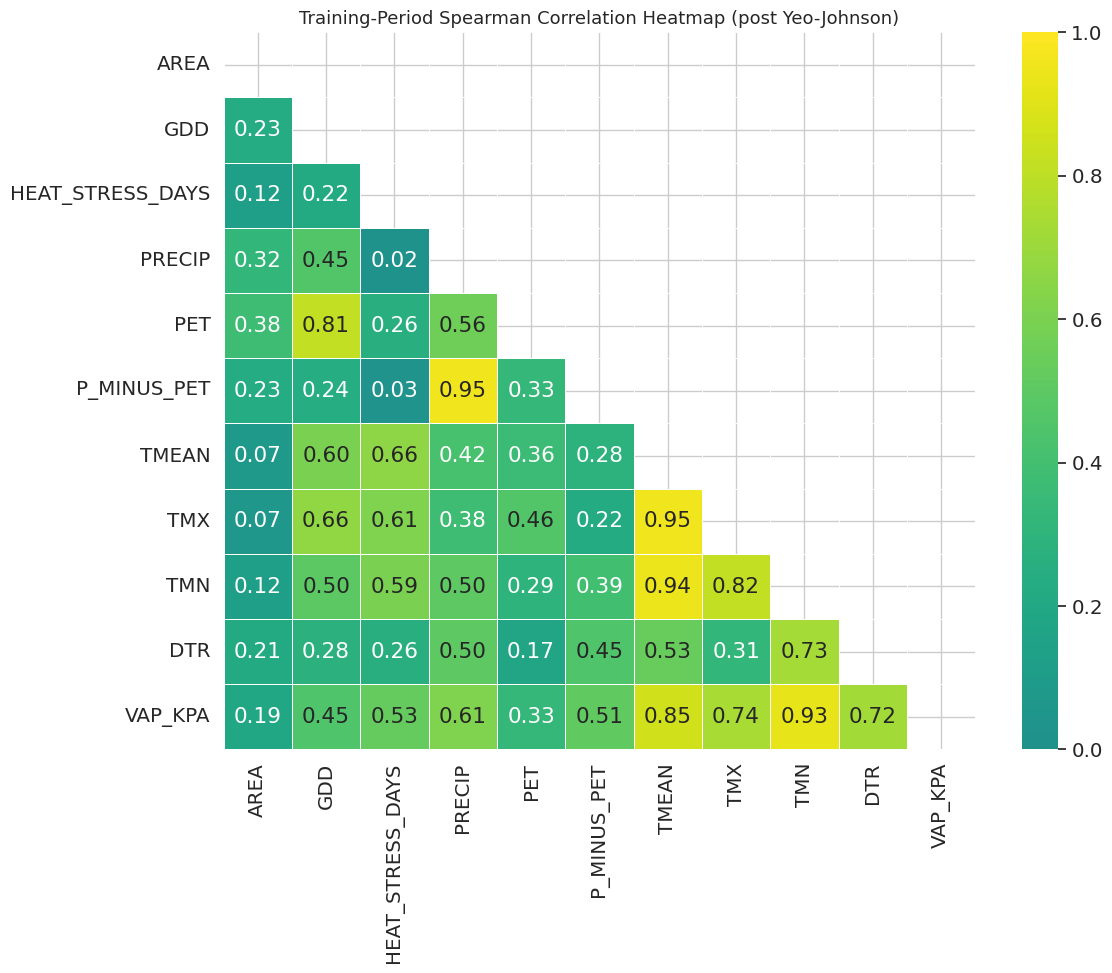

In [31]:
_num_eda = [
    c for c in df_eda.select_dtypes(include="number").columns
    if c not in ["YEAR", "PRODUCTION", "YIELD"]
]

corr_mat = df_eda[_num_eda].corr(method="spearman").abs()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(
    corr_mat,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    center=0,
    vmin=0,
    vmax=1,
    ax=ax,
    linewidths=0.5,
)
ax.set_title("Training-Period Spearman Correlation Heatmap (post Yeo-Johnson)", fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_spearman_heatmap.png", bbox_inches="tight", dpi=150)
plt.show()


In [32]:
# Highly correlated pairs (|r| > 0.85)
upper = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))
high_pairs = upper.stack()[upper.stack() > 0.85].reset_index()
high_pairs.columns = ["Feature1", "Feature2", "Spearman_r"]
print("Highly correlated pairs (|r| > 0.85):")
print(high_pairs.sort_values("Spearman_r", ascending=False).to_string(index=False))


Highly correlated pairs (|r| > 0.85):
Feature1    Feature2  Spearman_r
   TMEAN         TMX    0.954395
  PRECIP P_MINUS_PET    0.954150
   TMEAN         TMN    0.942541
     TMN     VAP_KPA    0.928368
   TMEAN     VAP_KPA    0.854911


In [33]:
# VIF analysis
_vif_df = df_eda[_num_eda].dropna()
vif_data = pd.DataFrame({
    "Feature": _vif_df.columns,
    "VIF"    : [variance_inflation_factor(_vif_df.values, i) for i in range(_vif_df.shape[1])],
}).sort_values("VIF", ascending=False)

print("\nVariance Inflation Factor (VIF):")
print(vif_data.to_string(index=False))
print("\nVIF > 10 indicates severe multicollinearity.")



Variance Inflation Factor (VIF):
         Feature         VIF
             TMX 4369.833740
             TMN 2217.403081
             DTR 1827.954494
           TMEAN  870.501290
             PET  626.870043
         VAP_KPA  465.505878
          PRECIP  263.802263
             GDD  130.529767
HEAT_STRESS_DAYS   64.056605
     P_MINUS_PET   26.652413
            AREA    5.426469

VIF > 10 indicates severe multicollinearity.


In [34]:
# ── Drop redundant collinear features ─────────────────────────────────────────
# Decision rationale (informed by Spearman heatmap + VIF):
#   PRECIP vs P_MINUS_PET  → keep PRECIP (direct rainfall; P_MINUS_PET is a derived ratio)
#   TMEAN  vs TMX, TMN     → keep TMEAN  (mean temperature; TMX/TMN are redundant extremes)
#   TMEAN  vs VAP_KPA      → keep TMEAN  (both highly correlated; TMEAN is more interpretable)
#
# After removal, CLIMATE_COLS (the global variable used by all downstream steps) is set.

COLS_TO_DROP_MULTICOLLINEAR = ["P_MINUS_PET", "TMX", "TMN", "VAP_KPA"]
raw_df = raw_df.drop(columns=COLS_TO_DROP_MULTICOLLINEAR, errors="ignore")
df_eda = df_eda.drop(columns=COLS_TO_DROP_MULTICOLLINEAR, errors="ignore")

# Update the global CLIMATE_COLS list used by feature engineering & anomaly computation
CLIMATE_COLS = [c for c in CLIMATE_COLS_RAW if c in raw_df.columns]
print(f"Retained climate columns ({len(CLIMATE_COLS)}): {CLIMATE_COLS}")
print(f"Remaining dataframe columns: {raw_df.columns.tolist()}")


Retained climate columns (6): ['GDD', 'HEAT_STRESS_DAYS', 'PRECIP', 'PET', 'TMEAN', 'DTR']
Remaining dataframe columns: ['DISTRICT', 'YEAR', 'PRODUCTION', 'AREA', 'YIELD', 'GDD', 'HEAT_STRESS_DAYS', 'PRECIP', 'PET', 'TMEAN', 'DTR', 'CROP']


###Outlier Detection

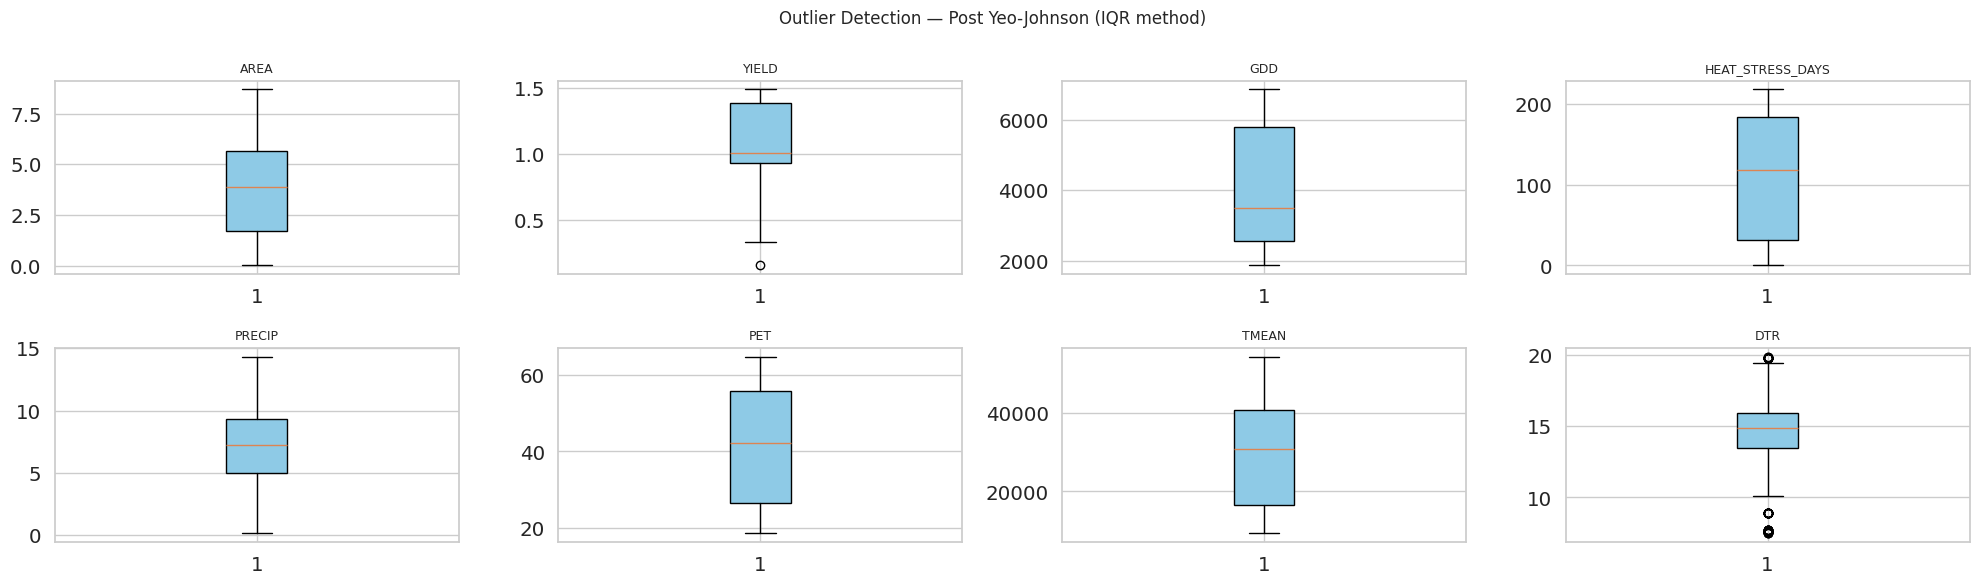

In [35]:
_out_cols = [c for c in df_eda.select_dtypes(include="number").columns
             if c not in ["YEAR", "PRODUCTION"]]

N_COLS = 4
N_ROWS = int(np.ceil(len(_out_cols) / N_COLS))
fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(20, N_ROWS * 3))
axes = axes.flatten()
for i, col in enumerate(_out_cols):
    axes[i].boxplot(df_eda[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor="#8ECAE6"))
    axes[i].set_title(col, fontsize=9)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Outlier Detection — Post Yeo-Johnson (IQR method)", fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_outliers.png", bbox_inches="tight", dpi=150)
plt.show()


In [36]:
# IQR outlier counts overall
print("Outlier counts per feature (IQR method) — post Yeo-Johnson:")
outlier_counts = {}
for col in _out_cols:
    Q1, Q3 = df_eda[col].quantile(0.25), df_eda[col].quantile(0.75)
    IQR    = Q3 - Q1
    outlier_counts[col] = int(((df_eda[col] < Q1 - 1.5*IQR) | (df_eda[col] > Q3 + 1.5*IQR)).sum())
print(pd.Series(outlier_counts).sort_values(ascending=False).to_string())


Outlier counts per feature (IQR method) — post Yeo-Johnson:
DTR                 60
YIELD                1
GDD                  0
AREA                 0
HEAT_STRESS_DAYS     0
PRECIP               0
PET                  0
TMEAN                0


In [37]:
# IQR outlier counts per (CROP, DISTRICT) group - YIELD only, training years only
def iqr_outliers(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return int(((series < Q1 - 1.5 * IQR) | (series > Q3 + 1.5 * IQR)).sum())

grp_outliers = eda_source_df.groupby(["CROP", "DISTRICT"])["YIELD"].apply(iqr_outliers)
print("Groups with YIELD outliers (IQR, train years only):")
print(grp_outliers[grp_outliers > 0].to_string())


Groups with YIELD outliers (IQR, train years only):
CROP       DISTRICT  
COTTON     Badin         1
           Dadu          1
           Ghotki        1
           Hyderabad     2
           Jamshoro      1
           Karachi       5
           Khairpur      1
           Larkana       4
           Matiari       2
           Mirpurkhas    1
           Nawabshah     1
           Sanghar       2
           Tharparkar    3
           Thatta        3
           Umarkot       1
RICE       Badin         2
           Dadu          1
           Hyderabad     1
           Jacobabad     1
           Jamshoro      2
           Kashmore      6
           Khairpur      3
           Matiari       1
           Nawabshah     3
           Sanghar       1
           Thatta        2
SUGARCANE  Badin         2
           Dadu          1
           Ghotki        3
           Hyderabad     4
           Jamshoro      5
           Kashmore      1
           Khairpur      3
           Larkana       2
        

###Multi-Method Correlation Analysis

> Five complementary measures are used to detect both linear and non-linear relationships:
>
> | Method | What it captures |
> |---|---|
> | Pearson  | Linear correlation |
> | Spearman | Monotonic (rank) correlation |
> | Kendall  | Ordinal concordance |
> | DistCorr | Any dependence including non-monotonic |
> | RDC      | Non-linear via random projections |
>
> A feature is retained if **any method** produces |signal| ≥ 0.30.  
> If `DistCorr − |Spearman| > 0.15` the relationship is flagged as non-linear.


In [38]:
def rdc(x, y, k=20, s=1/6, f=np.sin):
    """Randomised Dependence Coefficient — detects any relationship shape."""
    x = np.array(x, dtype=float).reshape(-1, 1)
    y = np.array(y, dtype=float).reshape(-1, 1)
    n = len(x)
    x = (np.argsort(np.argsort(x, axis=0), axis=0) + 1) / (n + 1)
    y = (np.argsort(np.argsort(y, axis=0), axis=0) + 1) / (n + 1)
    rng = np.random.default_rng(42)
    Wx = rng.normal(0, s, (1, k)); bx = rng.uniform(0, 2*np.pi, (1, k))
    Wy = rng.normal(0, s, (1, k)); by = rng.uniform(0, 2*np.pi, (1, k))
    Phix = np.hstack([f(x @ Wx + bx), np.ones((n, 1))])
    Phiy = np.hstack([f(y @ Wy + by), np.ones((n, 1))])
    Phix -= Phix.mean(0); Phiy -= Phiy.mean(0)
    Sxx = Phix.T @ Phix / n + 1e-10 * np.eye(k + 1)
    Syy = Phiy.T @ Phiy / n + 1e-10 * np.eye(k + 1)
    Sxy = Phix.T @ Phiy / n
    T   = np.linalg.solve(Sxx, Sxy) @ np.linalg.solve(Syy, Sxy.T)
    return float(np.sqrt(np.linalg.eigvalsh(T).max()))

def dist_corr(x, y):
    """Distance correlation — detects any dependence including non-monotonic."""
    x, y = np.array(x), np.array(y)
    def dcov(a, b):
        a = np.abs(a[:, None] - a[None, :])
        b = np.abs(b[:, None] - b[None, :])
        a = a - a.mean(axis=0) - a.mean(axis=1)[:, None] + a.mean()
        b = b - b.mean(axis=0) - b.mean(axis=1)[:, None] + b.mean()
        return np.sqrt(max((a * b).mean(), 0))
    num   = dcov(x, y)
    denom = np.sqrt(dcov(x, x) * dcov(y, y))
    return float(num / denom) if denom > 0 else 0.0


In [39]:
_corr_climate = [c for c in CLIMATE_COLS if c in df_eda.columns]
analysis_df = df_eda[_corr_climate + ["YIELD"]].dropna()

corr_comparison = pd.DataFrame(
    index=_corr_climate,
    columns=["Pearson", "Spearman", "Kendall", "DistCorr", "RDC"],
    dtype=float,
)
for feat in _corr_climate:
    valid = analysis_df[["YIELD", feat]].dropna()
    corr_comparison.loc[feat, "Pearson"] = float(valid["YIELD"].corr(valid[feat], method="pearson"))
    corr_comparison.loc[feat, "Spearman"] = float(valid["YIELD"].corr(valid[feat], method="spearman"))
    corr_comparison.loc[feat, "Kendall"] = float(kendalltau(valid["YIELD"].values, valid[feat].values)[0])
    corr_comparison.loc[feat, "DistCorr"] = dist_corr(valid["YIELD"].values, valid[feat].values)
    corr_comparison.loc[feat, "RDC"] = rdc(valid["YIELD"].values, valid[feat].values)

corr_comparison = corr_comparison.round(3)
print("Training-period feature-to-target correlations:")
print(corr_comparison.to_string())


Training-period feature-to-target correlations:
                  Pearson  Spearman  Kendall  DistCorr     RDC
GDD                 0.335     0.221    0.203     0.529  23.493
HEAT_STRESS_DAYS   -0.665    -0.496   -0.333     0.751   7.932
PRECIP              0.399     0.419    0.286     0.418  15.050
PET                 0.677     0.611    0.420     0.728   7.375
TMEAN               0.093     0.128    0.068     0.456  14.375
DTR                -0.069    -0.124   -0.082     0.196  10.421


In [40]:
print("\nNon-linear signal detected (DistCorr − |Spearman| > 0.15):")
nl = corr_comparison[corr_comparison["DistCorr"] - corr_comparison["Spearman"].abs() > 0.15]
print(nl[["Spearman", "DistCorr"]] if len(nl) else "  None — all relationships appear monotonic.")



Non-linear signal detected (DistCorr − |Spearman| > 0.15):
                  Spearman  DistCorr
GDD                  0.221     0.529
HEAT_STRESS_DAYS    -0.496     0.751
TMEAN                0.128     0.456


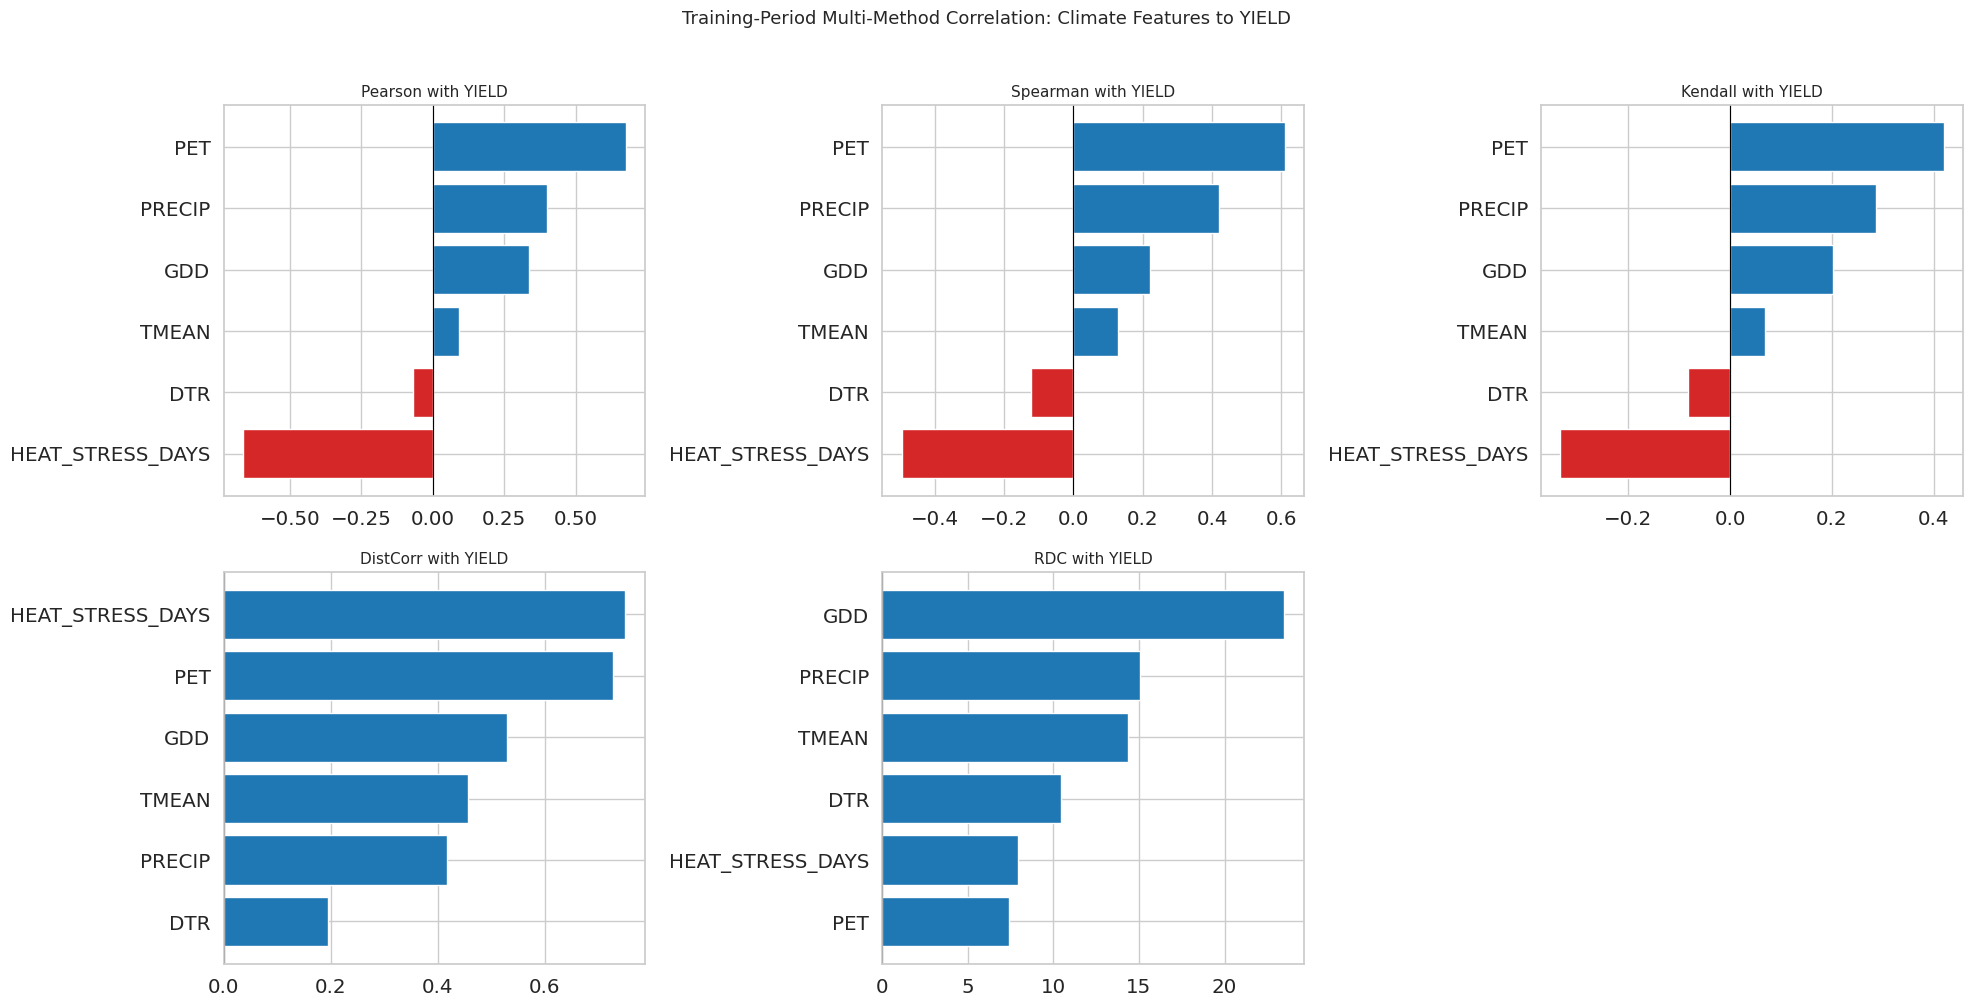

In [41]:
# Bar charts - one panel per correlation method (training years only)
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()
for i, method in enumerate(["Pearson", "Spearman", "Kendall", "DistCorr", "RDC"]):
    vals = corr_comparison[method].sort_values()
    colors_bar = ["#d62728" if v < 0 else "#1f77b4" for v in vals]
    axes[i].barh(vals.index, vals.values, color=colors_bar, edgecolor="white")
    axes[i].axvline(0, color="black", linewidth=0.8)
    axes[i].set_title(f"{method} with YIELD", fontsize=11)
axes[-1].set_visible(False)
plt.suptitle("Training-Period Multi-Method Correlation: Climate Features to YIELD", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_correlation_bars.png", bbox_inches="tight", dpi=150)
plt.show()


In [42]:
# Feature-level decision: KEEP if any measure ≥ 0.30
feature_report = []
for col in _corr_climate:
    p  = abs(corr_comparison.loc[col, "Pearson"])
    sp = abs(corr_comparison.loc[col, "Spearman"])
    dc =     corr_comparison.loc[col, "DistCorr"]
    max_signal = max(p, sp, dc)
    rel_type   = "NON-LINEAR" if (dc - sp) > 0.15 else ("LINEAR" if sp >= 0.3 else "WEAK")
    decision   = "KEEP" if max_signal >= 0.30 else "DROP"
    feature_report.append({
        "Feature"  : col,
        "Type"     : rel_type,
        "|Pearson|": round(p, 3),
        "|Spearman|": round(sp, 3),
        "DistCorr" : round(dc, 3),
        "MaxSignal": round(max_signal, 3),
        "Decision" : decision,
    })

report_df = pd.DataFrame(feature_report).set_index("Feature")
print("\nFeature correlation decisions:")
print(report_df.to_string())

# Update CLIMATE_COLS to only retained features
CLIMATE_COLS = [f for f in report_df[report_df["Decision"] == "KEEP"].index.tolist()
                if f in raw_df.columns]
_dropped_corr = report_df[report_df["Decision"] == "DROP"].index.tolist()
print(f"\nRetained ({len(CLIMATE_COLS)}): {CLIMATE_COLS}")
print(f"Dropped  ({len(_dropped_corr)}): {_dropped_corr}")



Feature correlation decisions:
                        Type  |Pearson|  |Spearman|  DistCorr  MaxSignal Decision
Feature                                                                          
GDD               NON-LINEAR      0.335       0.221     0.529      0.529     KEEP
HEAT_STRESS_DAYS  NON-LINEAR      0.665       0.496     0.751      0.751     KEEP
PRECIP                LINEAR      0.399       0.419     0.418      0.419     KEEP
PET                   LINEAR      0.677       0.611     0.728      0.728     KEEP
TMEAN             NON-LINEAR      0.093       0.128     0.456      0.456     KEEP
DTR                     WEAK      0.069       0.124     0.196      0.196     DROP

Retained (5): ['GDD', 'HEAT_STRESS_DAYS', 'PRECIP', 'PET', 'TMEAN']
Dropped  (1): ['DTR']


---
##Feature Engineering

> **Leakage safeguards applied here:**  
> - All lag and rolling features use `shift(1)` - the current row never sees its own target.  
> - Climate anomalies are computed from training group means only, then frozen before application to validation/test rows.  
> - `YEAR_INDEX` is derived purely from the year value itself - no target information involved.  
> - Climate feature selection in the EDA section is based on **pre-2020 training years only**.


In [43]:
def build_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Engineer leakage-safe features from the raw panel.

    Features added
    --------------
    - {CLIMATE_COL}_lag1        : 1-year lagged climate variable
    - {CLIMATE_COL}_roll3_mean  : 3-year rolling mean of lagged climate
    - YIELD_lag{1,2,3}          : lagged target (1–3 years)
    - AREA_lag1                 : 1-year lagged area
    - YIELD_roll3_{mean,std}    : 3-year rolling statistics of lagged yield
    - AREA_roll3_mean           : 3-year rolling mean of lagged area
    - YEAR_INDEX                : years since first observation per panel

    Rows that cannot satisfy the minimum history requirement are dropped.

    Note: VPD, RH (constant) and multicollinear features (P_MINUS_PET, TMX, TMN, VAP_KPA)
    have already been removed from df before this function is called.
    """
    work = df.copy()
    work = work.sort_values(["DISTRICT", "CROP", "YEAR"]).reset_index(drop=True)

    # Climate lags & rolling means — using only retained CLIMATE_COLS
    for col in CLIMATE_COLS:
        if col not in work.columns:
            continue
        work[f"{col}_lag1"] = work.groupby(["DISTRICT", "CROP"])[col].shift(1)
        work[f"{col}_roll3_mean"] = (
            work.groupby(["DISTRICT", "CROP"])[col]
            .shift(1)
            .groupby([work["DISTRICT"], work["CROP"]])
            .transform(lambda s: s.rolling(3, min_periods=2).mean())
        )

    # Yield & area history
    for lag in [1, 2, 3]:
        work[f"YIELD_lag{lag}"] = work.groupby(["DISTRICT", "CROP"])["YIELD"].shift(lag)

    work["AREA_lag1"] = work.groupby(["DISTRICT", "CROP"])["AREA"].shift(1)

    work["YIELD_roll3_mean"] = (
        work.groupby(["DISTRICT", "CROP"])["YIELD"]
        .shift(1)
        .groupby([work["DISTRICT"], work["CROP"]])
        .transform(lambda s: s.rolling(3, min_periods=2).mean())
    )
    work["YIELD_roll3_std"] = (
        work.groupby(["DISTRICT", "CROP"])["YIELD"]
        .shift(1)
        .groupby([work["DISTRICT"], work["CROP"]])
        .transform(lambda s: s.rolling(3, min_periods=2).std())
    )
    work["AREA_roll3_mean"] = (
        work.groupby(["DISTRICT", "CROP"])["AREA"]
        .shift(1)
        .groupby([work["DISTRICT"], work["CROP"]])
        .transform(lambda s: s.rolling(3, min_periods=2).mean())
    )

    # Long-run panel trend (leakage-safe: derived from year value only)
    work["YEAR_INDEX"] = work["YEAR"] - work.groupby(["DISTRICT", "CROP"])["YEAR"].transform("min")

    # Drop rows that cannot satisfy minimum history requirements
    required_history_cols = [
        "YIELD_lag1", "YIELD_lag2", "YIELD_lag3",
        "AREA_lag1",  "YIELD_roll3_mean", "YIELD_roll3_std", "AREA_roll3_mean",
    ]
    work = work.dropna(subset=required_history_cols).reset_index(drop=True)
    work["YEAR"] = work["YEAR"].astype(int)
    return work


In [44]:
engineered_df = build_features(raw_df)

print(f"Rows after feature engineering   : {len(engineered_df):,}")
print(f"Columns after feature engineering: {engineered_df.shape[1]}")
print(f"Year range in engineered data    : {engineered_df['YEAR'].min()} – {engineered_df['YEAR'].max()}")


Rows after feature engineering   : 1,342
Columns after feature engineering: 30
Year range in engineered data    : 2003 – 2024


In [45]:
engineered_df.head()

,DISTRICT,YEAR,PRODUCTION,AREA,YIELD,GDD,HEAT_STRESS_DAYS,PRECIP,PET,TMEAN,...,TMEAN_lag1,TMEAN_roll3_mean,YIELD_lag1,YIELD_lag2,YIELD_lag3,AREA_lag1,YIELD_roll3_mean,YIELD_roll3_std,AREA_roll3_mean,YEAR_INDEX
0,Badin,2003,64.73,7.29,8.87,3056.600140,184.0,317.80000,38.900000,31.616669,...,32.066670,31.783335,4.62,19.35,10.91,16.97,11.626667,7.391105,11.926667,3
1,Badin,2004,20.26,4.75,4.27,3074.800152,184.0,81.70000,39.400000,31.716667,...,31.616669,31.772224,8.87,4.62,19.35,7.29,10.946667,7.581400,10.296667,4
2,Badin,2005,19.19,5.68,3.38,3065.200117,184.0,163.70001,39.100002,31.666666,...,31.716667,31.800002,4.27,8.87,4.62,4.75,5.920000,2.560762,9.670000,5
3,Badin,2006,46.00,9.36,4.91,3103.300198,184.0,351.10000,39.100002,31.866669,...,31.666666,31.666667,3.38,4.27,8.87,5.68,5.506667,2.946529,5.906667,6
4,Badin,2007,64.91,14.97,4.34,3096.300175,184.0,275.40000,39.400000,31.833334,...,31.866669,31.750001,4.91,3.38,4.27,9.36,4.186667,0.768397,6.596667,7


---
##Preprocessing Helpers

> The preprocessor is always **fit on training data only** and then applied to validation/test — no leakage.


In [46]:
def build_feature_columns(df: pd.DataFrame) -> list:
    """Return all columns except the target (YIELD) and its raw proxy (PRODUCTION)."""
    drop_cols = {"PRODUCTION", "YIELD"}
    return [col for col in df.columns if col not in drop_cols]

def build_preprocessor(
    feature_df: pd.DataFrame,
    categorical_cols: list | None = None,
) -> tuple:
    """
    Build a ColumnTransformer that:
    - Imputes + Yeo-Johnson transforms numeric columns.
    - Imputes + one-hot encodes categorical columns.

    Returns
    -------
    preprocessor, numeric_cols, categorical_cols
    """
    if categorical_cols is None:
        categorical_cols = [col for col in ["DISTRICT", "CROP"] if col in feature_df.columns]

    numeric_cols = [col for col in feature_df.columns if col not in categorical_cols]

    numeric_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("power",   PowerTransformer(method="yeo-johnson", standardize=True)),
    ])
    categorical_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot",  OneHotEncoder(handle_unknown="ignore")),
    ])

    preprocessor = ColumnTransformer(transformers=[
        ("num", numeric_pipe,     numeric_cols),
        ("cat", categorical_pipe, categorical_cols),
    ])
    return preprocessor, numeric_cols, categorical_cols


In [47]:
def add_train_only_anomalies(
    train_df: pd.DataFrame,
    valid_df: pd.DataFrame,
    anomaly_cols: Iterable[str],
    group_cols: list | None = None,
) -> tuple:
    """
    Compute climate anomaly features (deviation from group mean).

    Group means are computed from training data only, then frozen
    before being applied to the validation/test set.
    Unseen validation/test groups fall back to the global train mean.
    """
    train_df = train_df.copy()
    valid_df = valid_df.copy()
    anomaly_cols = [col for col in anomaly_cols if col in train_df.columns]

    if group_cols is None:
        group_cols = ["DISTRICT", "CROP"]

    group_means = train_df.groupby(group_cols)[anomaly_cols].mean().reset_index()
    global_means = train_df[anomaly_cols].mean()

    train_df = train_df.merge(group_means, on=group_cols, how="left", suffixes=("", "_group_mean"))
    valid_df = valid_df.merge(group_means, on=group_cols, how="left", suffixes=("", "_group_mean"))

    for col in anomaly_cols:
        mean_col = f"{col}_group_mean"
        train_ref = train_df[mean_col].fillna(global_means[col])
        valid_ref = valid_df[mean_col].fillna(global_means[col])
        train_df[f"{col}_anomaly"] = train_df[col] - train_ref
        valid_df[f"{col}_anomaly"] = valid_df[col] - valid_ref

    drop_cols = [f"{col}_group_mean" for col in anomaly_cols]
    train_df = train_df.drop(columns=drop_cols, errors="ignore")
    valid_df = valid_df.drop(columns=drop_cols, errors="ignore")
    return train_df, valid_df

def build_tabular_arrays(
    train_df: pd.DataFrame,
    valid_df: pd.DataFrame,
    categorical_cols: list | None = None,
) -> tuple:
    """Fit preprocessor on train, transform both splits."""
    feature_cols = build_feature_columns(train_df)
    preprocessor, _, _ = build_preprocessor(train_df[feature_cols], categorical_cols=categorical_cols)
    X_train = preprocessor.fit_transform(train_df[feature_cols])
    X_valid = preprocessor.transform(valid_df[feature_cols])
    y_train = train_df["YIELD"].to_numpy()
    y_valid = valid_df["YIELD"].to_numpy()
    return X_train, X_valid, y_train, y_valid, feature_cols


In [48]:
# ============================================================
# Export artifacts for Model Training & Testing.ipynb
# ============================================================

ARTIFACT_DIR = OUTPUT_DIR / "preprocessing_artifacts"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

ENGINEERED_DATA_PATH = ARTIFACT_DIR / "engineered_df.csv"
PROFILE_PATH = ARTIFACT_DIR / "profile.json"
METADATA_PATH = ARTIFACT_DIR / "metadata.json"

engineered_df.to_csv(ENGINEERED_DATA_PATH, index=False)

with open(PROFILE_PATH, "w", encoding="utf-8") as f:
    json.dump(profile, f, indent=2)

metadata = {
    "final_test_start": FINAL_TEST_START,
    "random_state": RANDOM_STATE,
    "window": WINDOW,
    "dl_n_runs": DL_N_RUNS,
    "max_epochs": MAX_EPOCHS,
    "dl_verbose": DL_VERBOSE,
    "climate_cols": CLIMATE_COLS,
    "climate_cols_raw": CLIMATE_COLS_RAW,
    "feature_columns": build_feature_columns(engineered_df),
    "target_column": "YIELD",
    "year_min": int(engineered_df["YEAR"].min()),
    "year_max": int(engineered_df["YEAR"].max()),
    "rows": int(len(engineered_df)),
}

with open(METADATA_PATH, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print("Saved preprocessing artifacts:")
print(f"engineered_df: {ENGINEERED_DATA_PATH}")
print(f"profile      : {PROFILE_PATH}")
print(f"metadata     : {METADATA_PATH}")

Saved preprocessing artifacts:
engineered_df: /content/outputs/preprocessing_artifacts/engineered_df.csv
profile      : /content/outputs/preprocessing_artifacts/profile.json
metadata     : /content/outputs/preprocessing_artifacts/metadata.json
